# Open-Loop VR: Spatial Modulation Comparison (Diamanti et al. 2021 replication)

**Experimental design (V1 prism animals, n=3)**
- Day 7: Active VR, closed-loop
- Day 8: Running replay (open-loop, animal can run freely)
- Day 9: Stationary replay (open-loop, animal immobilized)

**Prerequisites — run in order before this notebook:**
1. `Preprocess_OpenLoopVR.py` → generates `*_preproc*.h5` for Day 8 and Day 9
   - Day 7 `*_preproc*.h5` should already exist from the standard pipeline
2. `SMI_OpenLoopVR_Batch.py` → generates `*_smi_results.h5` for Day 8 and Day 9
   - Day 7 `*_smi_results.h5` should already exist from `SMI_FullSession_Batch.py`

**Analysis plan**
- Analysis 1: Population-level SMI comparison (Diamanti et al. replication)
- Analysis 2: Layer-specific SMI comparison (novel contribution)

**Figures**
1. Cumulative SMI distributions — all 3 conditions (population level)
2. Scatter plots — Day 7 vs Day 8 and Day 7 vs Day 9 (median per session)
3. Layer-specific cumulative SMI distributions (3 conditions × 4 layers)
4. SMI reduction magnitude by layer — violin plots
5. Summary statistics table

---
## Setup

In [37]:
import sys
sys.path.insert(0, r'C:\Users\jasmineyeo\Documents\GitHub\V1_SpatialModulation')

import os
import glob
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rcParams
from scipy import stats

%matplotlib inline

rcParams['legend.fontsize'] = 20
rcParams['axes.labelsize']  = 20
rcParams['axes.titlesize']  = 25
rcParams['xtick.labelsize'] = 20
rcParams['ytick.labelsize'] = 20

CONDITIONS  = ['Day7_ClosedLoop', 'Day8_RunningReplay', 'Day9_StationaryReplay']
COND_LABELS = ['Day 7\n(Active VR)', 'Day 8\n(Running replay)', 'Day 9\n(Stationary replay)']
COND_COLORS = ['#2196F3', '#FF9800', '#E53935']

LAYER_NAMES  = ['L2/3', 'L4', 'L5', 'L6']
LAYER_COLORS = ['#1E88E5', '#FF9800', '#4CAF50', '#E53935']

# Per-animal output dirs are set in SESSIONS.
# Cross-animal figures go here:
ACROSS_ANIMALS_DIR = r'D:\V1_SpatialModulation\2p\V1_prism\across_animals_OpenLoopVR_Analysis'

# Colors for individual animals in cross-animal overlay plots
ANIMAL_COLORS = ['#9C27B0', '#009688', '#FF5722', '#607D8B', '#795548',
                 '#E91E63', '#3F51B5', '#00BCD4', '#8BC34A', '#FFC107']

print('Setup complete.')

Setup complete.


---
## Session paths
Edit this cell to point to each animal's session files.

In [38]:
SESSIONS = [
    {
        'animal_id'              : 'JSY044',
        'lastday_smi'            : r'D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\250912_JSY_JSY044_SpatialModulation_Day7\TSeries-09122025-1334-001\JSY044_Day7_smi_results.h5',
        # 'lastday_smi'            : r'D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\250910_JSY_JSY044_SpatialModulation_Day5\TSeries-09102025-1340-001\JSY044_Day5_smi_results.h5',
        'openloop_active_smi'    : r'D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\251122_JSY_JSY044_SpMod_OpenLoopVR_Moving\TSeries-11222025-1339-001\JSY044_OpenloopVR_moving_smi_results.h5',
        'openloop_stationary_smi': r'D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\251123_JSY_JSY044_SpMod_OpenLoopVR_Stationary\TSeries-11232025-1222-001\JSY044_OpenloopVR_stationary_smi_results.h5',
        'lastday_preproc'        : r'D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\250912_JSY_JSY044_SpatialModulation_Day7\TSeries-09122025-1334-001',
        # 'lastday_preproc'        : r'D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\250910_JSY_JSY044_SpatialModulation_Day5\TSeries-09102025-1340-001',
        'output_dir'             : r'D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\OpenLoopVR_Analysis_day7',
    },
    {
        'animal_id'              : 'JSY051',
        # 'lastday_smi'            : r'D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\251105_JSY_JSY051_SpMod_Day5\TSeries-11052025-1512-002\JSY051_Day5_smi_results.h5',
        'lastday_smi'            : r'D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\251104_JSY_JSY051_SpMod_Day4\TSeries-11042025-1418-001\JSY051_Day4_smi_results.h5',
        'openloop_active_smi'    : r'D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\251106_JSY_JSY051_SpMO_OpenloopVR_moving\TSeries-11062025-1439-002\JSY051_OpenloopVR_moving_smi_results.h5',
        'openloop_stationary_smi': r'D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\251107_JSY_JSY051_SpMO_OpenloopVR_stationary\TSeries-11072025-1032-001\JSY051_OpenloopVR_stationary_smi_results.h5',
        # 'lastday_preproc'        : r'D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\251105_JSY_JSY051_SpMod_Day5\TSeries-11052025-1512-002',
        'lastday_preproc'        : r'D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\251104_JSY_JSY051_SpMod_Day4\TSeries-11042025-1418-001',
        'output_dir'             : r'D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\OpenLoopVR_Analysis_day4',
    },
    {
        'animal_id'              : 'JSY052',
        'lastday_smi'            : r'D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\251015_JSY_JSY052_SpatialModulation_Day7\TSeries-10152025-1103-001\JSY052_Day7_smi_results.h5',
        # 'lastday_smi'            : r'D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\251013_JSY_JSY052_SpatialModulation_Day5\TSeries-10132025-1236-001\JSY052_Day5_smi_results.h5',
        'openloop_active_smi'    : r'D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\251122_JSY_JSY052_SpMod_OpenLoopVR_Moving\TSeries-11222025-1339-001\JSY052_OpenloopVR_moving_smi_results.h5',
        'openloop_stationary_smi': r'D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\251123_JSY_JSY052_SpMod_OpenLoopVR_Stationary\TSeries-11232025-1222-002\JSY052_OpenloopVR_stationary_smi_results.h5',
        'lastday_preproc'        : r'D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\251015_JSY_JSY052_SpatialModulation_Day7\TSeries-10152025-1103-001',
        # 'lastday_preproc'        : r'D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\251013_JSY_JSY052_SpatialModulation_Day5\TSeries-10132025-1236-001',
        'output_dir'             : r'D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\OpenLoopVR_Analysis_day7',
    },
    {
        'animal_id'              : 'JSY054',
        'lastday_smi'            : r'D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\251105_JSY_JSY054_SpMod_Day7\TSeries-11052025-1512-001\JSY054_Day7_smi_results.h5',
        # 'lastday_smi'            : r'D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\251103_JSY_JSY054_SpMod_Day5\TSeries-11032025-1715-001\JSY054_Day5_smi_results.h5',
        'openloop_active_smi'    : r'D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\251106_JSY_JSY054_SpMO_OpenloopVR_moving\TSeries-11062025-1439-001\JSY054_OpenloopVR_moving_smi_results.h5',
        'openloop_stationary_smi': r'D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\251107_JSY_JSY054_SpMO_OpenloopVR_stationary\TSeries-11072025-1032-001\JSY054_OpenloopVR_stationary_smi_results.h5',
        'lastday_preproc'        : r'D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\251105_JSY_JSY054_SpMod_Day7\TSeries-11052025-1512-001',
        # 'lastday_preproc'        : r'D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\251103_JSY_JSY054_SpMod_Day5\TSeries-11032025-1715-001',
        'output_dir'             : r'D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\OpenLoopVR_Analysis_day7',
    },
        {
        'animal_id'              : 'JSY055',
        'lastday_smi'            : r'D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\251211_JSY_JSY055_SpatialModulation_Day7\TSeries-12112025-1631-001\JSY055_Day7_smi_results.h5',
        # 'lastday_smi'            : r'D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\251209_JSY_JSY055_SpatialModualtion_Day5\TSeries-12092025-2000-001\JSY055_Day5_smi_results.h5',
        'openloop_active_smi'    : r'D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\251212_JSY_JSY055_SpatialModulation_OpenLoopVR_Moving\TSeries-12122025-1421-001\JSY055_OpenloopVR_moving_smi_results.h5',
        'openloop_stationary_smi': r'D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\251213_JSY_JSY055_SpatialModulation_OpenLoopVR_Stationary\TSeries-12132025-1711-001\JSY055_OpenloopVR_stationary_smi_results.h5',
        'lastday_preproc'        : r'D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\251211_JSY_JSY055_SpatialModulation_Day7\TSeries-12112025-1631-001',
        # 'lastday_preproc'        : r'D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\251209_JSY_JSY055_SpatialModualtion_Day5\TSeries-12092025-2000-001',
        'output_dir'             : r'D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\OpenLoopVR_Analysis_day7',
    },

]

print(f'Sessions configured: {[s["animal_id"] for s in SESSIONS]}')

Sessions configured: ['JSY044', 'JSY051', 'JSY052', 'JSY054', 'JSY055']


In [39]:
# --- Animal inclusion selector ---
# Comment out any animal you want to exclude from all figures and statistics.
INCLUDE_ANIMALS = [
    'JSY044',
    'JSY051',
    'JSY052',
    'JSY054',
    'JSY055',
]

print(f'Animals included: {INCLUDE_ANIMALS}')

Animals included: ['JSY044', 'JSY051', 'JSY052', 'JSY054', 'JSY055']


---
## Data loading functions

In [40]:
def load_smi_h5(h5_path):
    """
    Load SMI results from a *_smi_results.h5 file.

    Returns a dict with keys:
      SMI_all    : (n_cells,)  full SMI array (0 for invalid cells)
      valid_mask : (n_cells,) bool  cells with a valid SMI value
      SMI        : (n_valid,)  SMI values for valid cells only
      median_smi, mad_smi, n_valid : summary scalars
      med_coords : (n_cells, 2)  [y, x] pixel coordinates
      bin_centers : (n_bins,)
      layers     : dict  keyed by 'L2/3','L4','L5','L6'
                         each value: {'SMI': array, 'cell_indices': array,
                                      'median_smi': float, 'mad_smi': float}
    """
    if not os.path.isfile(h5_path):
        raise FileNotFoundError(f'File not found: {h5_path}')

    data = {}
    with h5py.File(h5_path, 'r') as f:
        # Global SMI
        data['SMI_all']   = f['global_smi/SMI_all_cells'][:]
        data['valid_mask'] = f['global_smi/valid_cells_mask'][:].astype(bool)
        data['SMI']        = data['SMI_all'][data['valid_mask']]
        data['n_valid']    = int(f['global_smi'].attrs['n_valid_cells'])
        data['median_smi'] = float(f['global_smi'].attrs['median_smi'])
        data['mad_smi']    = float(f['global_smi'].attrs['mad_smi'])

        # Cell info
        data['med_coords']  = f['cell_info/med_coords'][:]
        data['bin_centers'] = f['cell_info/bin_centers'][:]

        # Layer-specific
        data['layers'] = {}
        layer_key_map = {'L2_3': 'L2/3', 'L4': 'L4', 'L5': 'L5', 'L6': 'L6'}
        for h5_key, display_name in layer_key_map.items():
            if h5_key in f.get('layer_smi', {}):
                grp = f['layer_smi'][h5_key]
                if 'SMI' in grp and len(grp['SMI']) > 0:
                    data['layers'][display_name] = {
                        'SMI'           : grp['SMI'][:],
                        'cell_indices'  : grp['cell_indices'][:],
                        'reliable_valid': grp['reliable_valid_cells'][:] if 'reliable_valid_cells' in grp else None,
                        'n_valid'       : int(grp.attrs.get('n_cells_valid', 0)),
                        'median_smi'    : float(grp.attrs.get('median_smi', np.nan)),
                        'mad_smi'       : float(grp.attrs.get('mad_smi', np.nan)),
                    }
    return data


def load_session(session_dict):
    """
    Load all three conditions for one animal.

    Returns a dict:
      {'Day7': data_lastday, 'Day8': data_openloop_active, 'Day9': data_openloop_stationary, 'animal_id': str}
    """
    out = {'animal_id': session_dict['animal_id']}
    for cond, key in [('Day7', 'lastday_smi'), ('Day8', 'openloop_active_smi'), ('Day9', 'openloop_stationary_smi')]:
        path = session_dict[key]
        print(f'  {cond}: {os.path.basename(path)}')
        out[cond] = load_smi_h5(path)
        print(f'    n_valid={out[cond]["n_valid"]}  '
              f'median SMI={out[cond]["median_smi"]:.3f} ± {out[cond]["mad_smi"]:.3f} (MAD)')
    return out

print('Functions defined.')

Functions defined.


---
## Step 1 — Load single session (verify)
Run this first after preprocessing to confirm data loads correctly.

Loading JSY044 last day...

  n_cells total : 847
  n_valid       : 271
  Median SMI    : 0.434 ± 0.162 (MAD)
  SMI range     : [-0.157, 0.968]
  Layers found  : ['L2/3', 'L4', 'L5', 'L6']


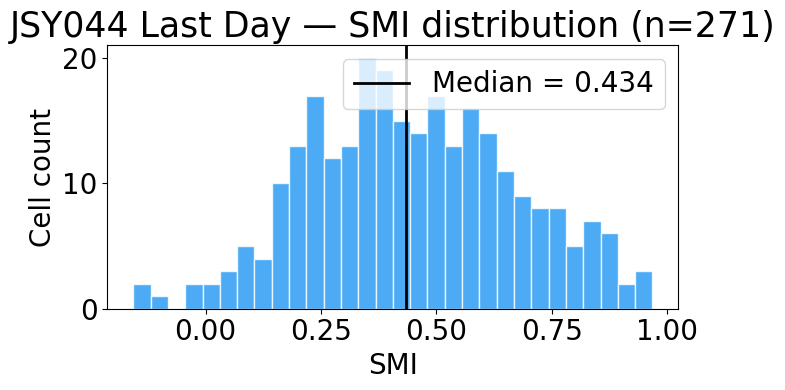

In [41]:
# --- verify last day for the first animal ---
s0 = SESSIONS[0]
print(f'Loading {s0["animal_id"]} last day...')
d7 = load_smi_h5(s0['lastday_smi'])

print(f'\n  n_cells total : {len(d7["SMI_all"])}')
print(f'  n_valid       : {d7["n_valid"]}')
print(f'  Median SMI    : {d7["median_smi"]:.3f} ± {d7["mad_smi"]:.3f} (MAD)')
print(f'  SMI range     : [{d7["SMI"].min():.3f}, {d7["SMI"].max():.3f}]')
print(f'  Layers found  : {list(d7["layers"].keys())}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(d7['SMI'], bins=30, color='#2196F3', edgecolor='white', alpha=0.8)
ax.axvline(d7['median_smi'], color='k', lw=2, label=f'Median = {d7["median_smi"]:.3f}')
ax.set_xlabel('SMI')
ax.set_ylabel('Cell count')
ax.set_title(f'{s0["animal_id"]} Last Day — SMI distribution (n={d7["n_valid"]})')
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 2 — Load all animals, all conditions

In [42]:
os.makedirs(ACROSS_ANIMALS_DIR, exist_ok=True)

all_sessions = []
for s in SESSIONS:
    if s["animal_id"] not in INCLUDE_ANIMALS:
        print(f'Skipping {s["animal_id"]} (not in INCLUDE_ANIMALS)')
        continue
    os.makedirs(s["output_dir"], exist_ok=True)
    print(f'Loading {s["animal_id"]}...')
    sess = load_session(s)
    sess["output_dir"] = s["output_dir"]
    sess["lastday_preproc"] = s["lastday_preproc"]
    sess["openloop_active_smi"] = s["openloop_active_smi"]
    sess["openloop_stationary_smi"] = s["openloop_stationary_smi"]
    all_sessions.append(sess)
    print(f'  Output dir : {s["output_dir"]}')

print(f'Loaded {len(all_sessions)} animals: {[s["animal_id"] for s in all_sessions]}')
print(f'Cross-animal output: {ACROSS_ANIMALS_DIR}')

Loading JSY044...
  Day7: JSY044_Day7_smi_results.h5
    n_valid=271  median SMI=0.434 ± 0.162 (MAD)
  Day8: JSY044_OpenloopVR_moving_smi_results.h5
    n_valid=156  median SMI=0.399 ± 0.140 (MAD)
  Day9: JSY044_OpenloopVR_stationary_smi_results.h5
    n_valid=233  median SMI=0.386 ± 0.150 (MAD)
  Output dir : D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\OpenLoopVR_Analysis_day7
Loading JSY051...
  Day7: JSY051_Day4_smi_results.h5
    n_valid=236  median SMI=0.603 ± 0.204 (MAD)
  Day8: JSY051_OpenloopVR_moving_smi_results.h5
    n_valid=315  median SMI=0.400 ± 0.208 (MAD)
  Day9: JSY051_OpenloopVR_stationary_smi_results.h5
    n_valid=339  median SMI=0.397 ± 0.165 (MAD)
  Output dir : D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\OpenLoopVR_Analysis_day4
Loading JSY052...
  Day7: JSY052_Day7_smi_results.h5
    n_valid=111  median SMI=0.762 ± 0.173 (MAD)
  Day8: JSY052_OpenloopVR_moving_smi_results.h5
    n_valid=232  median SMI=0.320 ± 0.184 (MAD)
  Day9: JSY05

---
## Figure 1 — Cumulative SMI distributions (population level, Diamanti et al. replication)

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\OpenLoopVR_Analysis_day7\Figure1_CDF_JSY044.png


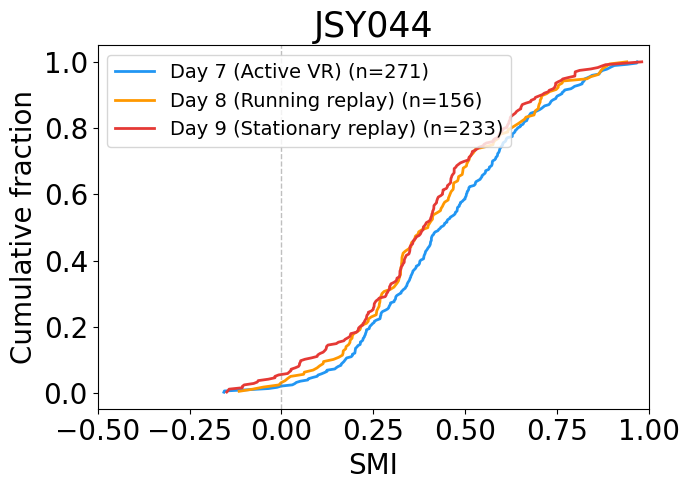

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\OpenLoopVR_Analysis_day4\Figure1_CDF_JSY051.png


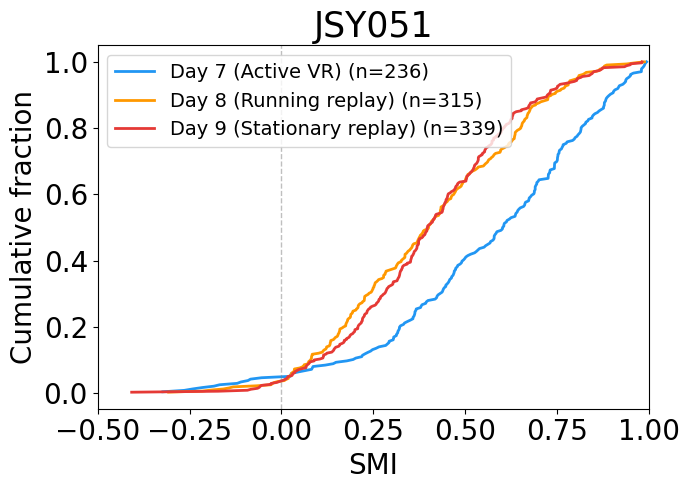

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\OpenLoopVR_Analysis_day7\Figure1_CDF_JSY052.png


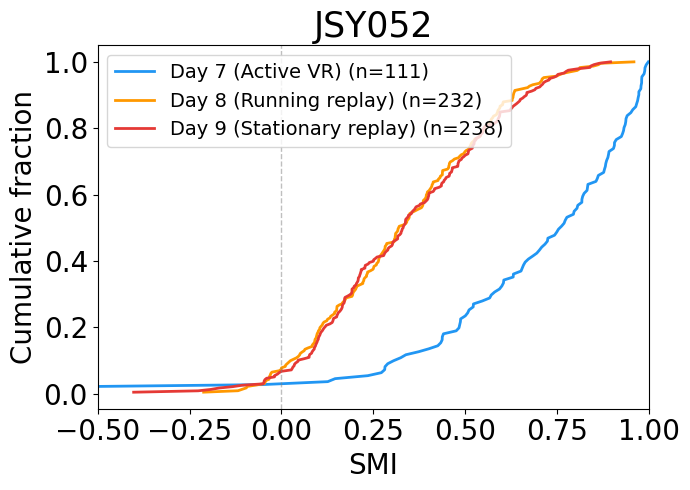

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\OpenLoopVR_Analysis_day7\Figure1_CDF_JSY054.png


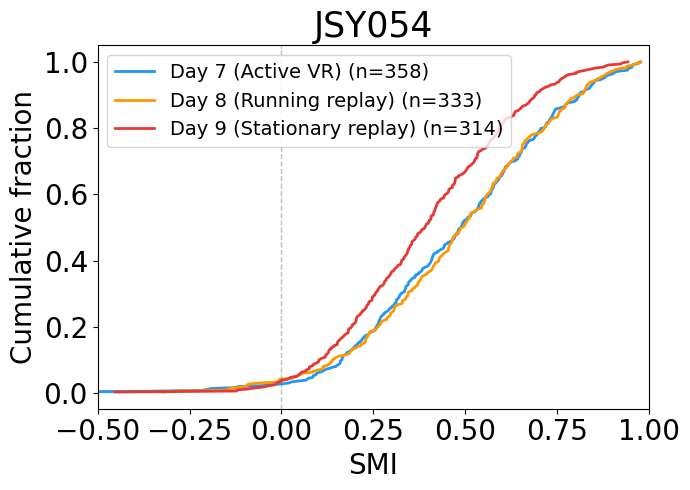

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\OpenLoopVR_Analysis_day7\Figure1_CDF_JSY055.png


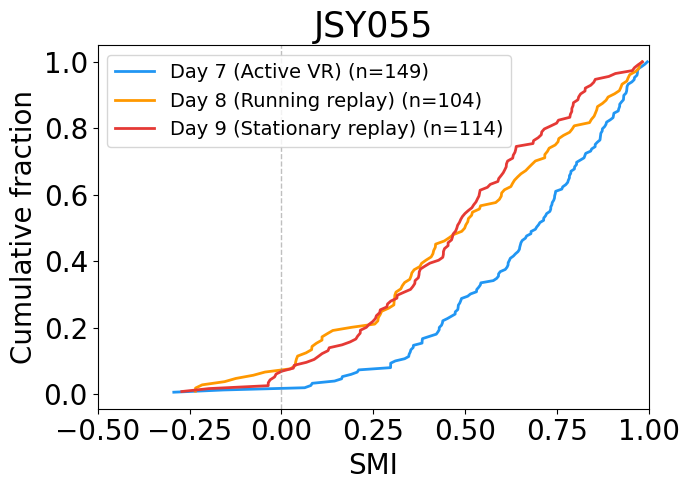

Saved: D:\V1_SpatialModulation\2p\V1_prism\across_animals_OpenLoopVR_Analysis\Figure1_CDF_AllAnimals.png


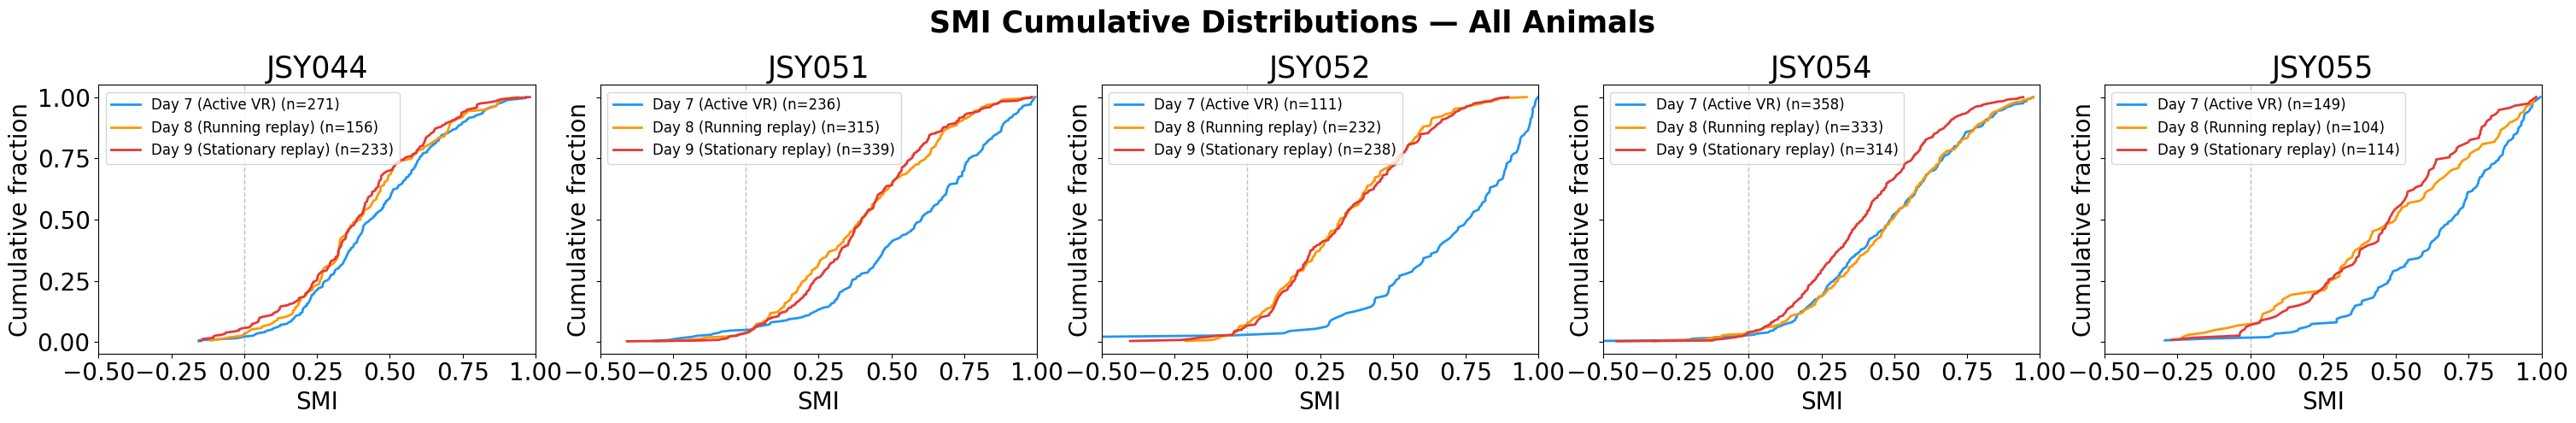

In [43]:
def plot_cdf(ax, smi_values, color, label, lw=2, **kwargs):
    sorted_smi = np.sort(smi_values)
    cdf = np.arange(1, len(sorted_smi) + 1) / len(sorted_smi)
    ax.plot(sorted_smi, cdf, color=color, lw=lw, label=label, **kwargs)


# --- Per-animal: one figure per animal ---
for sess in all_sessions:
    fig, ax = plt.subplots(figsize=(7, 5))
    for cond, color, label in zip(['Day7', 'Day8', 'Day9'], COND_COLORS, COND_LABELS):
        plot_cdf(ax, sess[cond]['SMI'], color=color,
                 label=f"{label.replace(chr(10), ' ')} (n={sess[cond]['n_valid']})")
    ax.axvline(0, color='gray', lw=1, ls='--', alpha=0.5)
    ax.set_xlabel('SMI'); ax.set_ylabel('Cumulative fraction')
    ax.set_title(sess['animal_id']); ax.legend(fontsize=14); ax.set_xlim(-0.5, 1.0)
    plt.tight_layout()
    save_path = os.path.join(sess['output_dir'], f'Figure1_CDF_{sess["animal_id"]}.png')
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved: {save_path}')
    plt.show()

# --- Cross-animal: all animals as subplots in one figure ---
fig, axes = plt.subplots(1, len(all_sessions), figsize=(6 * len(all_sessions), 5), sharey=True)
if len(all_sessions) == 1:
    axes = [axes]
for ax, sess in zip(axes, all_sessions):
    for cond, color, label in zip(['Day7', 'Day8', 'Day9'], COND_COLORS, COND_LABELS):
        plot_cdf(ax, sess[cond]['SMI'], color=color,
                 label=f"{label.replace(chr(10), ' ')} (n={sess[cond]['n_valid']})")
    ax.axvline(0, color='gray', lw=1, ls='--', alpha=0.5)
    ax.set_xlabel('SMI'); ax.set_ylabel('Cumulative fraction')
    ax.set_title(sess['animal_id']); ax.legend(fontsize=12); ax.set_xlim(-0.5, 1.0)
fig.suptitle('SMI Cumulative Distributions — All Animals', fontsize=25, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(ACROSS_ANIMALS_DIR, 'Figure1_CDF_AllAnimals.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

---
## Statistics — Wilcoxon signed-rank tests (population level)

In [44]:
print('='*70)
print('POPULATION-LEVEL STATISTICS')
print('='*70)

for sess in all_sessions:
    print(f'\n{sess["animal_id"]}')
    for cond in ['Day7', 'Day8', 'Day9']:
        d = sess[cond]
        print(f'  {cond}: median={d["median_smi"]:.3f} ± {d["mad_smi"]:.3f} (MAD), n={d["n_valid"]}')

    # Mann-Whitney U (unpaired) — cells are NOT tracked across sessions,
    # so indices differ between days; use independent-samples comparison.
    for cond_a, cond_b in [('Day7', 'Day8'), ('Day7', 'Day9')]:
        smi_a = sess[cond_a]['SMI']
        smi_b = sess[cond_b]['SMI']
        if len(smi_a) > 1 and len(smi_b) > 1:
            stat, p = stats.mannwhitneyu(smi_a, smi_b, alternative='two-sided')
            print(f'  {cond_a} vs {cond_b}: n_a={len(smi_a)}, n_b={len(smi_b)}, U={stat:.1f}, p={p:.4f}')
        else:
            print(f'  {cond_a} vs {cond_b}: insufficient data (n_a={len(smi_a)}, n_b={len(smi_b)})')

POPULATION-LEVEL STATISTICS

JSY044
  Day7: median=0.434 ± 0.162 (MAD), n=271
  Day8: median=0.399 ± 0.140 (MAD), n=156
  Day9: median=0.386 ± 0.150 (MAD), n=233
  Day7 vs Day8: n_a=271, n_b=156, U=23151.0, p=0.1012
  Day7 vs Day9: n_a=271, n_b=233, U=35639.0, p=0.0126

JSY051
  Day7: median=0.603 ± 0.204 (MAD), n=236
  Day8: median=0.400 ± 0.208 (MAD), n=315
  Day9: median=0.397 ± 0.165 (MAD), n=339
  Day7 vs Day8: n_a=236, n_b=315, U=50216.0, p=0.0000
  Day7 vs Day9: n_a=236, n_b=339, U=54204.0, p=0.0000

JSY052
  Day7: median=0.762 ± 0.173 (MAD), n=111
  Day8: median=0.320 ± 0.184 (MAD), n=232
  Day9: median=0.331 ± 0.180 (MAD), n=238
  Day7 vs Day8: n_a=111, n_b=232, U=21775.0, p=0.0000
  Day7 vs Day9: n_a=111, n_b=238, U=22173.0, p=0.0000

JSY054
  Day7: median=0.489 ± 0.187 (MAD), n=358
  Day8: median=0.495 ± 0.174 (MAD), n=333
  Day9: median=0.391 ± 0.171 (MAD), n=314
  Day7 vs Day8: n_a=358, n_b=333, U=59070.0, p=0.8379
  Day7 vs Day9: n_a=358, n_b=314, U=67802.0, p=0.0000

JSY

---
## Figure 2 — Scatter plots per session (Diamanti et al. Figure 4f style)
Each dot = median SMI of one session.

Saved: D:\V1_SpatialModulation\2p\V1_prism\across_animals_OpenLoopVR_Analysis\Figure2_Scatter_SessionMedian.png


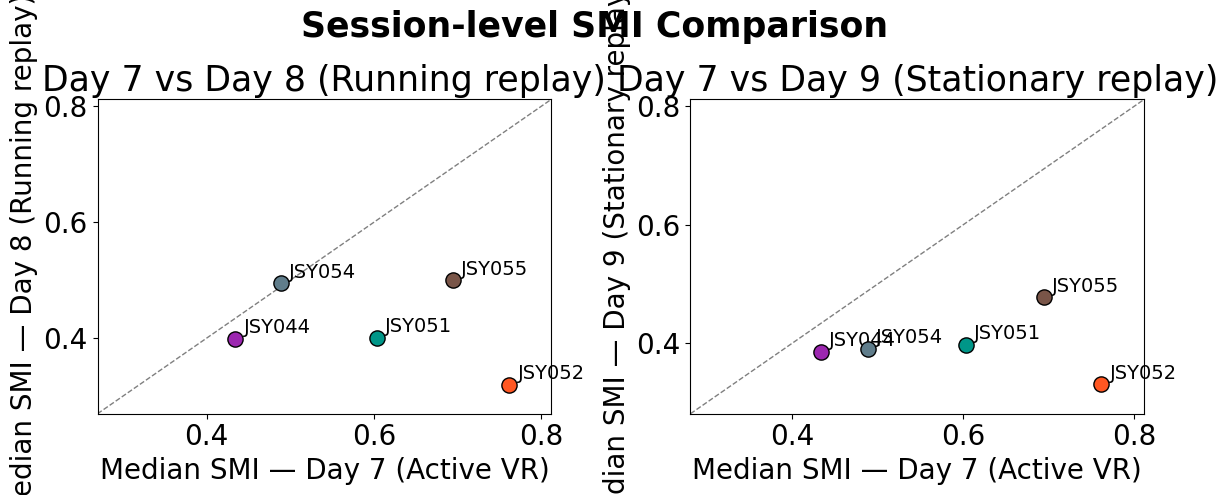

In [45]:
# Figure 2 is inherently cross-animal (each dot = one animal median).
# Saved only to ACROSS_ANIMALS_DIR.

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

medians_d7 = [s['Day7']['median_smi'] for s in all_sessions]
medians_d8 = [s['Day8']['median_smi'] for s in all_sessions]
medians_d9 = [s['Day9']['median_smi'] for s in all_sessions]
animal_ids = [s['animal_id'] for s in all_sessions]

for ax, medians_other, other_label, color in [
    (axes[0], medians_d8, 'Day 8 (Running replay)',    COND_COLORS[1]),
    (axes[1], medians_d9, 'Day 9 (Stationary replay)', COND_COLORS[2]),
]:
    for ac, x, y in zip(ANIMAL_COLORS, medians_d7, medians_other):
        ax.scatter(x, y, s=120, color=ac, zorder=5, edgecolors='k', lw=1)
    for aid, x, y in zip(animal_ids, medians_d7, medians_other):
        ax.annotate(aid, (x, y), textcoords='offset points', xytext=(6, 4), fontsize=14)

    lim = [min(min(medians_d7), min(medians_other)) - 0.05,
           max(max(medians_d7), max(medians_other)) + 0.05]
    ax.plot(lim, lim, 'k--', lw=1, alpha=0.5)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Median SMI — Day 7 (Active VR)')
    ax.set_ylabel(f'Median SMI — {other_label}')
    ax.set_title(f'Day 7 vs {other_label}')

fig.suptitle('Session-level SMI Comparison', fontsize=25, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(ACROSS_ANIMALS_DIR, 'Figure2_Scatter_SessionMedian.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

---
## Figure 3 — Layer-specific cumulative SMI distributions (3 conditions × 4 layers)

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\OpenLoopVR_Analysis_day7\Figure3_LayerCDF_JSY044.png


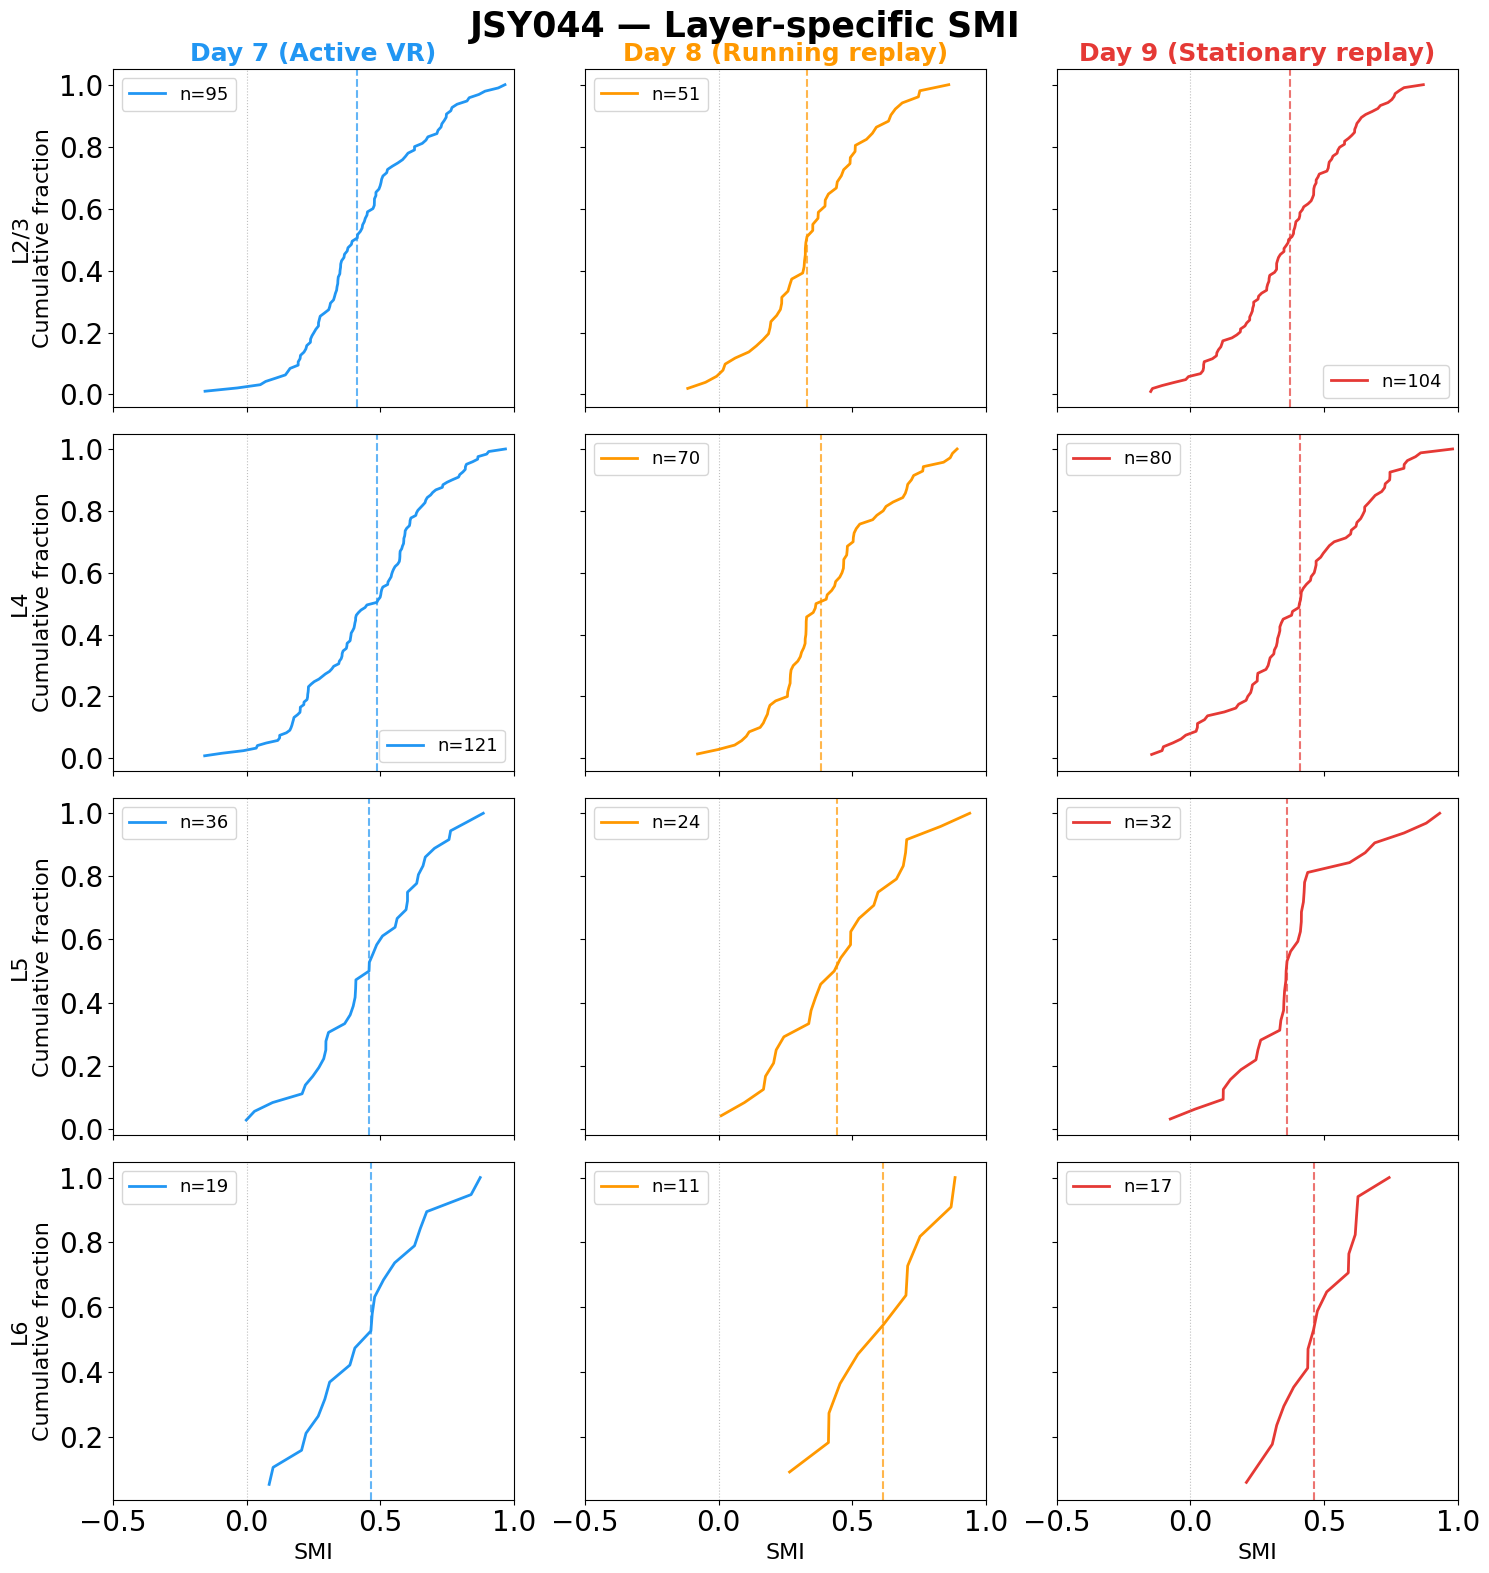

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\OpenLoopVR_Analysis_day4\Figure3_LayerCDF_JSY051.png


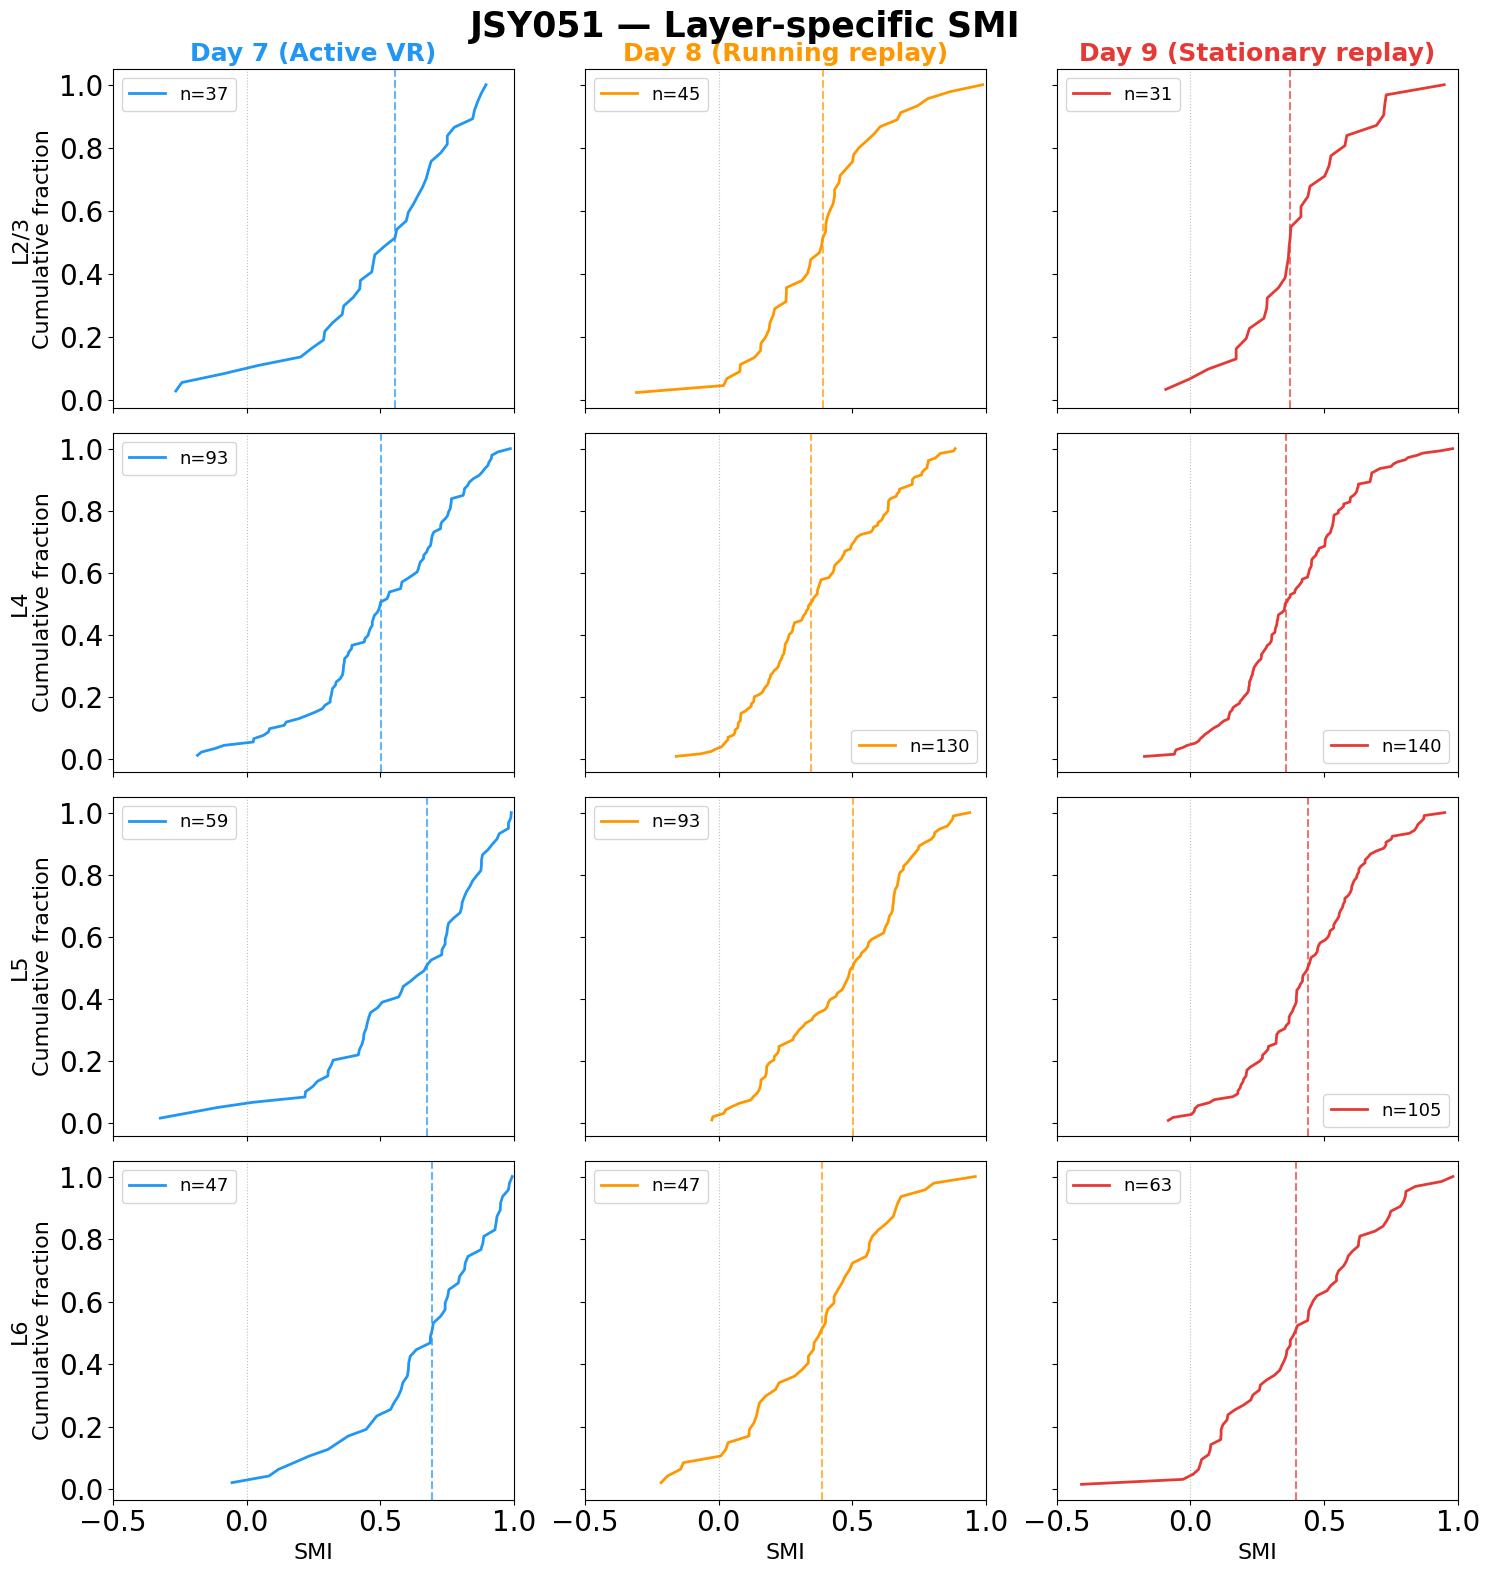

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\OpenLoopVR_Analysis_day7\Figure3_LayerCDF_JSY052.png


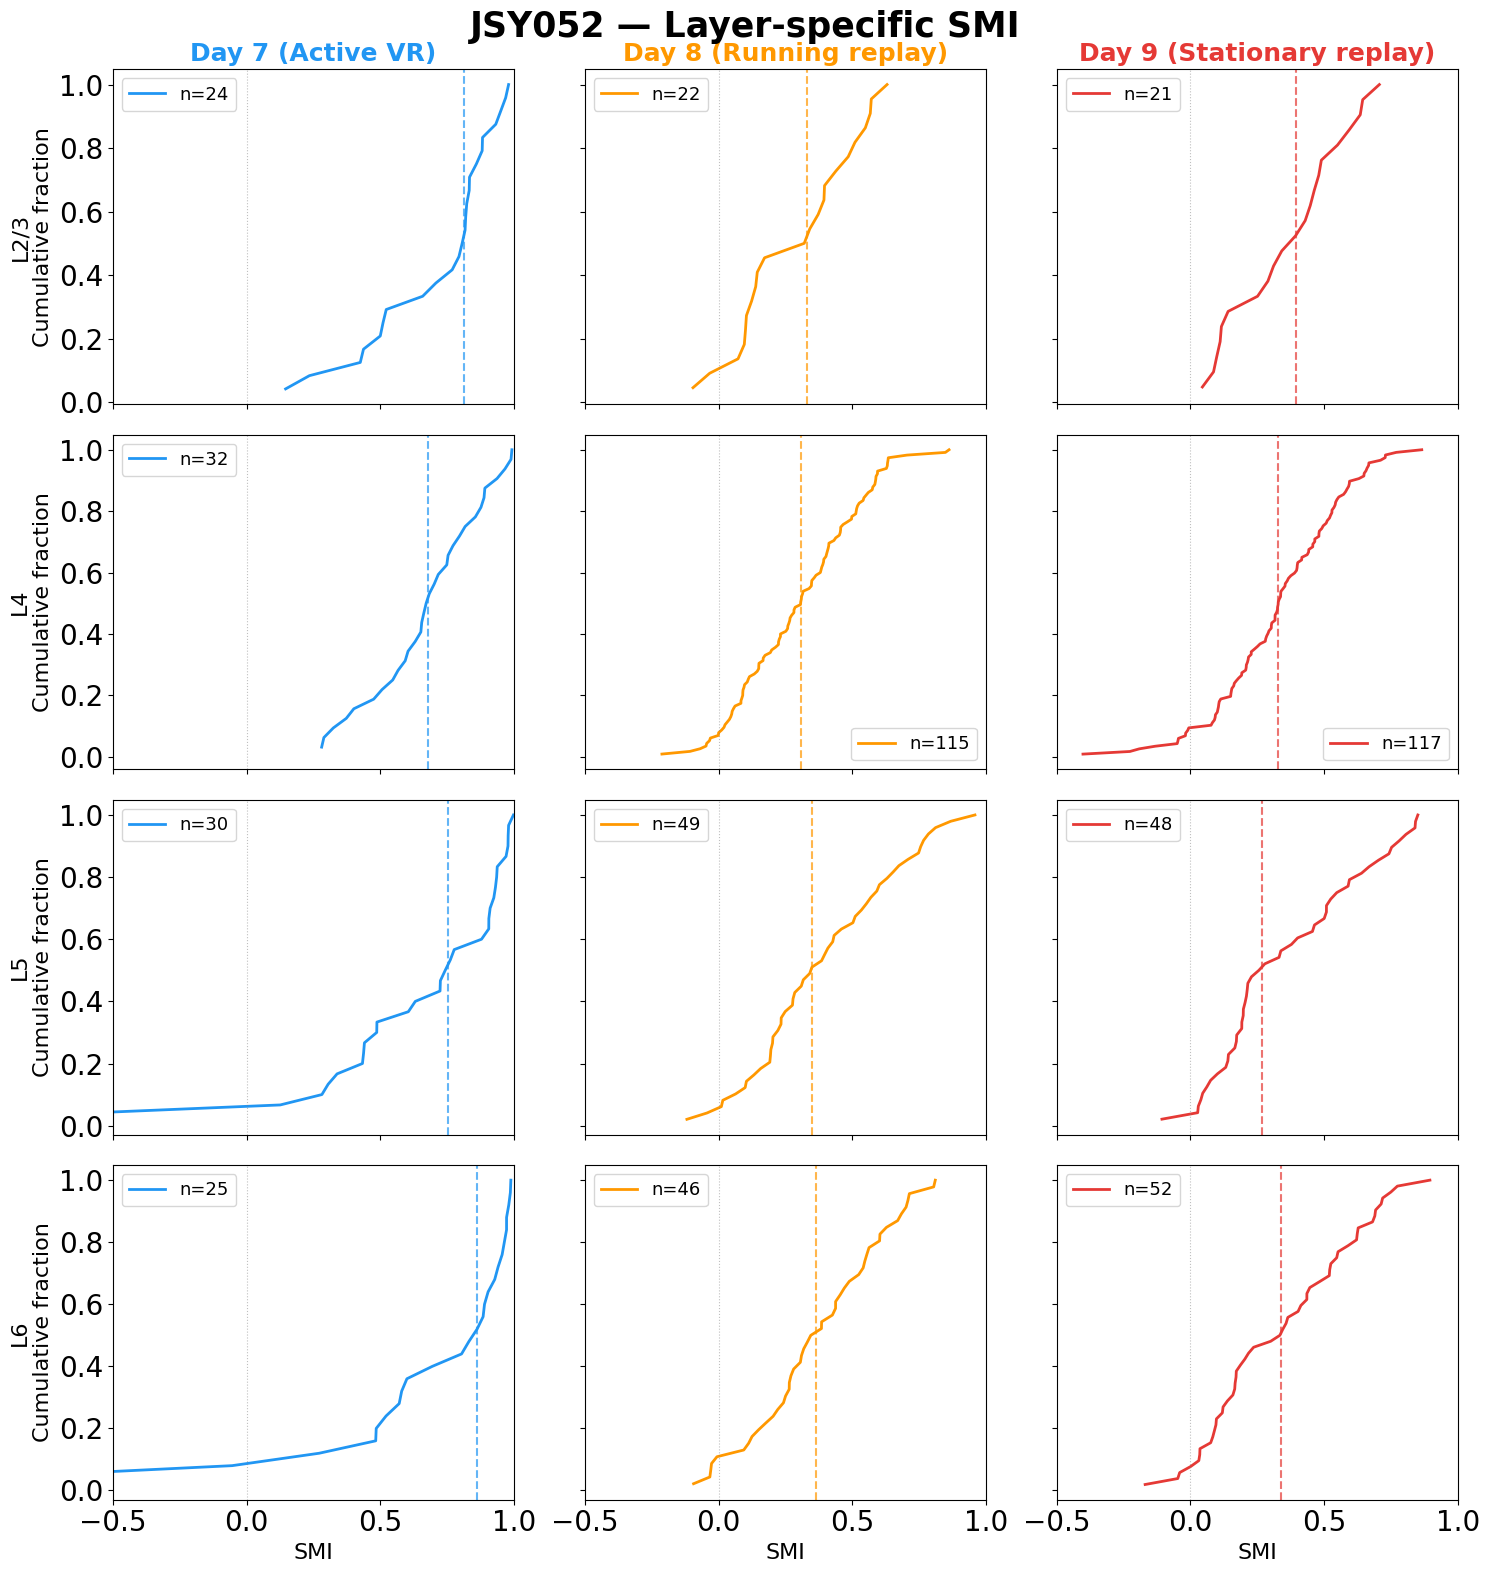

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\OpenLoopVR_Analysis_day7\Figure3_LayerCDF_JSY054.png


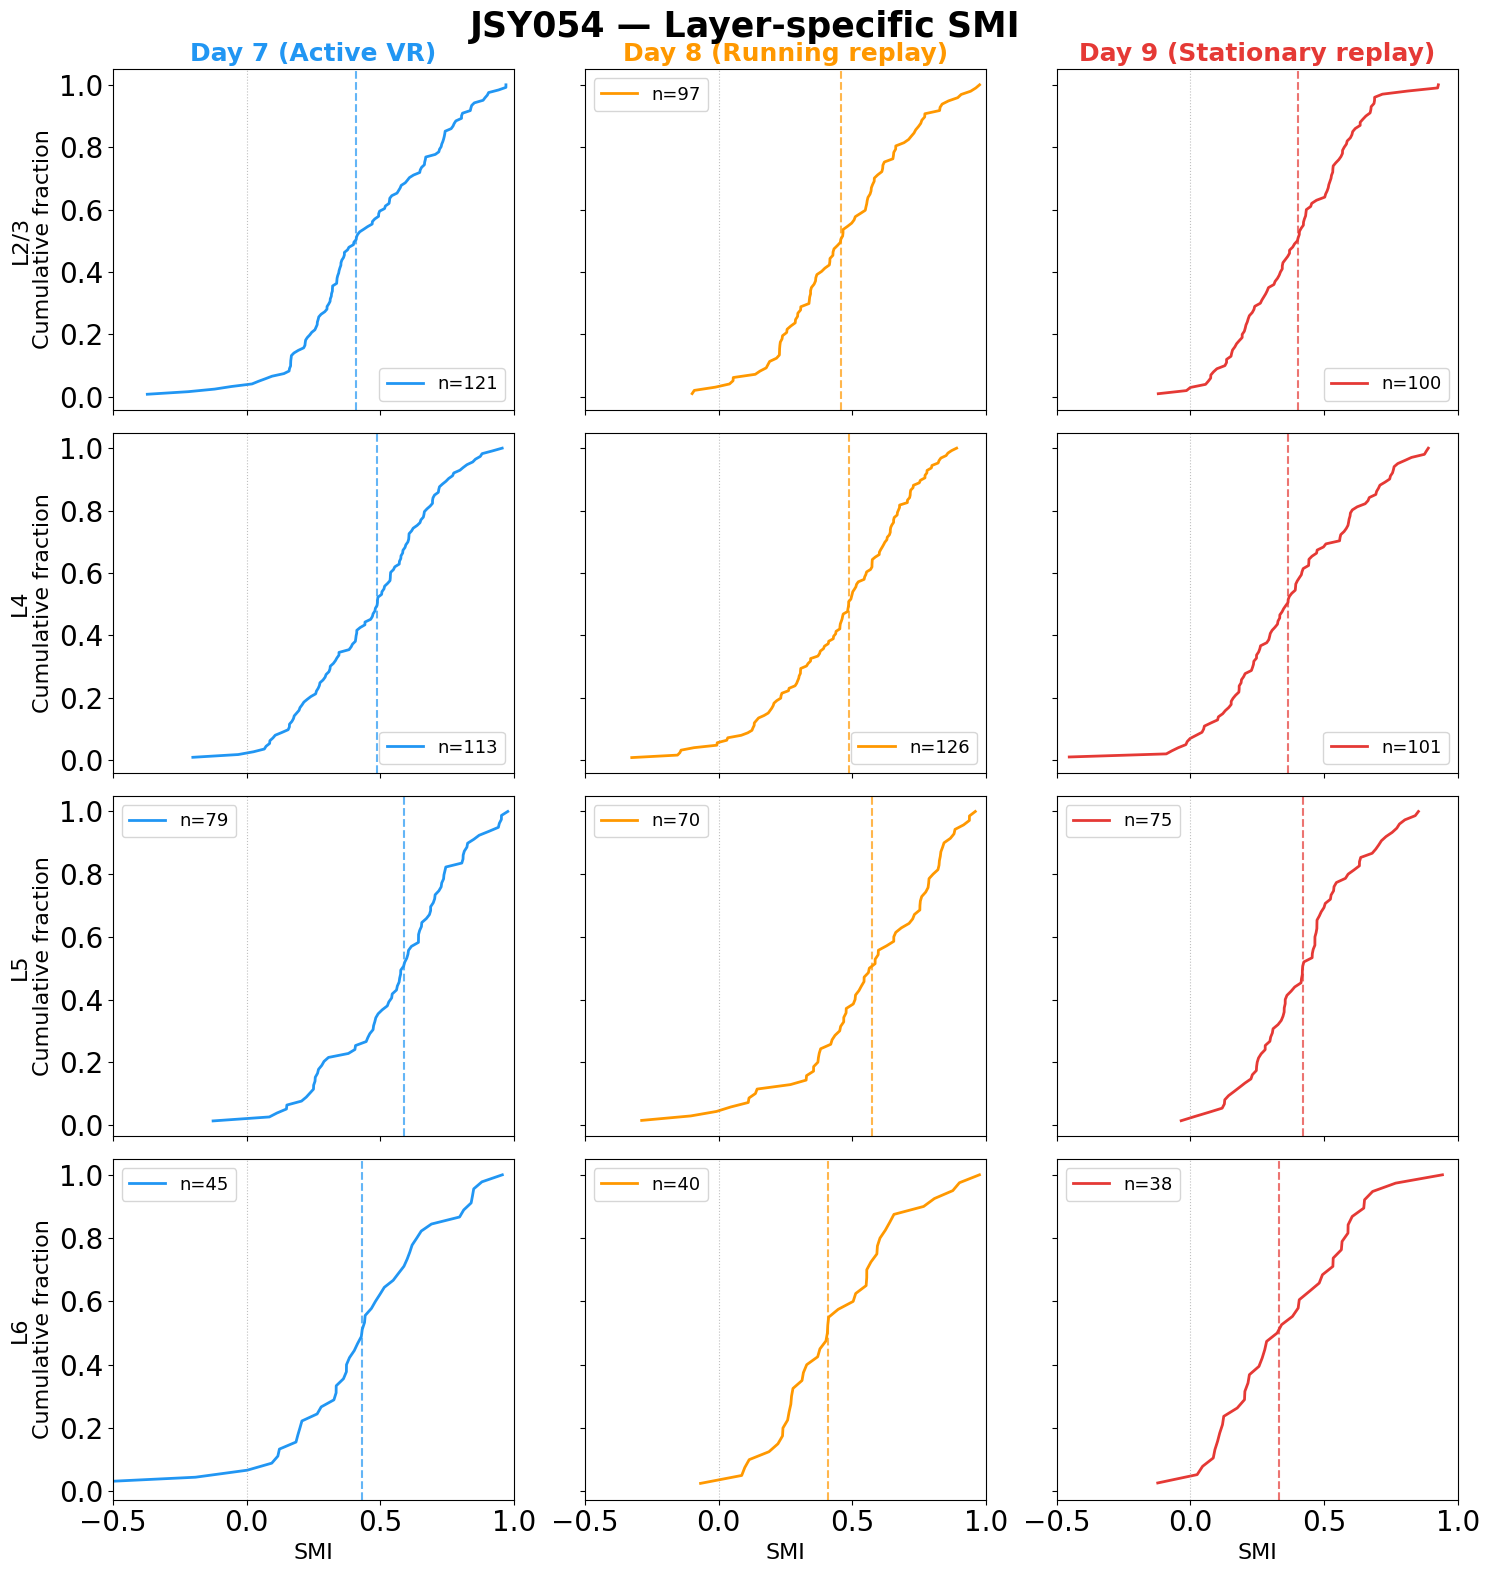

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\OpenLoopVR_Analysis_day7\Figure3_LayerCDF_JSY055.png


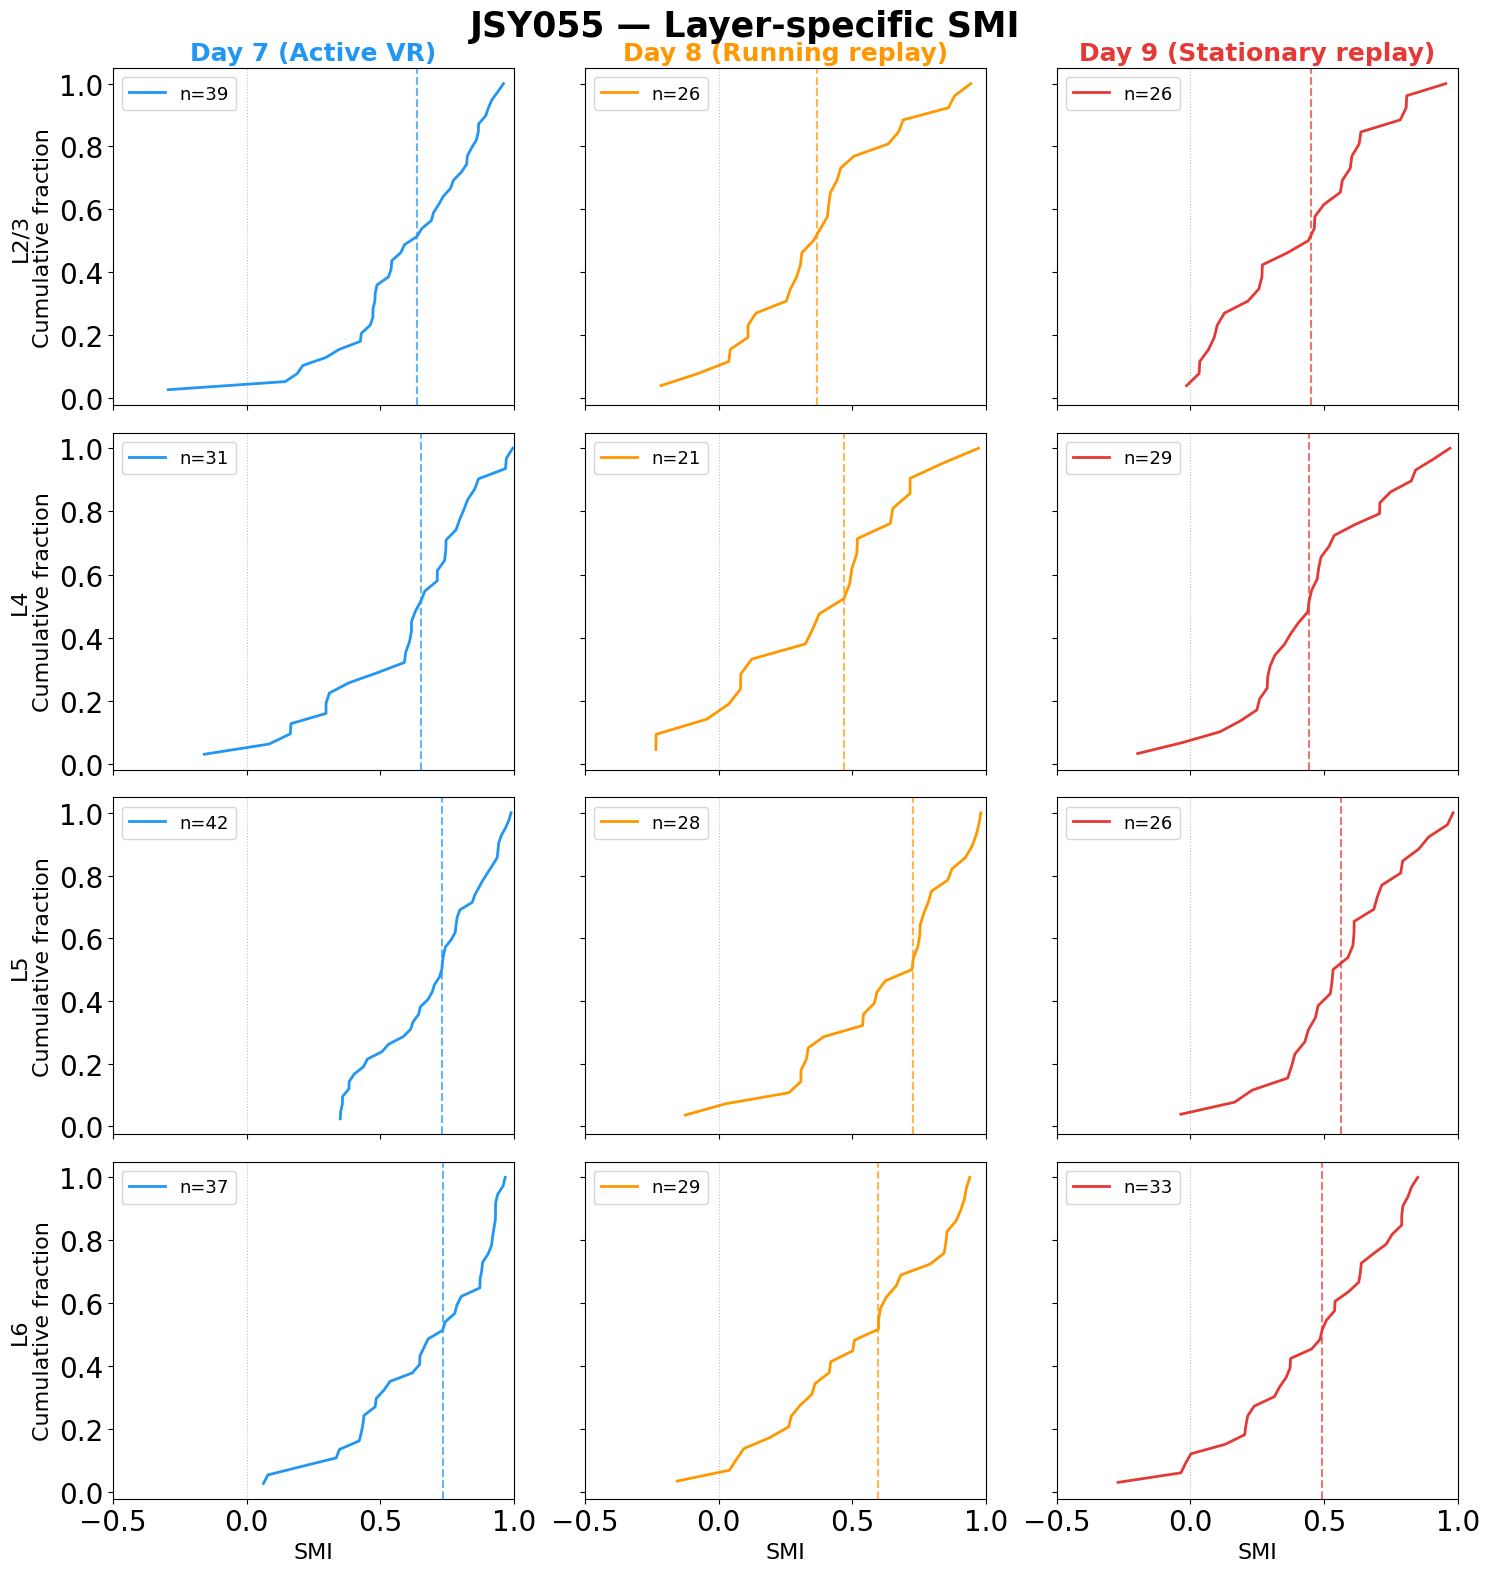

Saved: D:\V1_SpatialModulation\2p\V1_prism\across_animals_OpenLoopVR_Analysis\Figure3_LayerCDF_AllAnimals.png


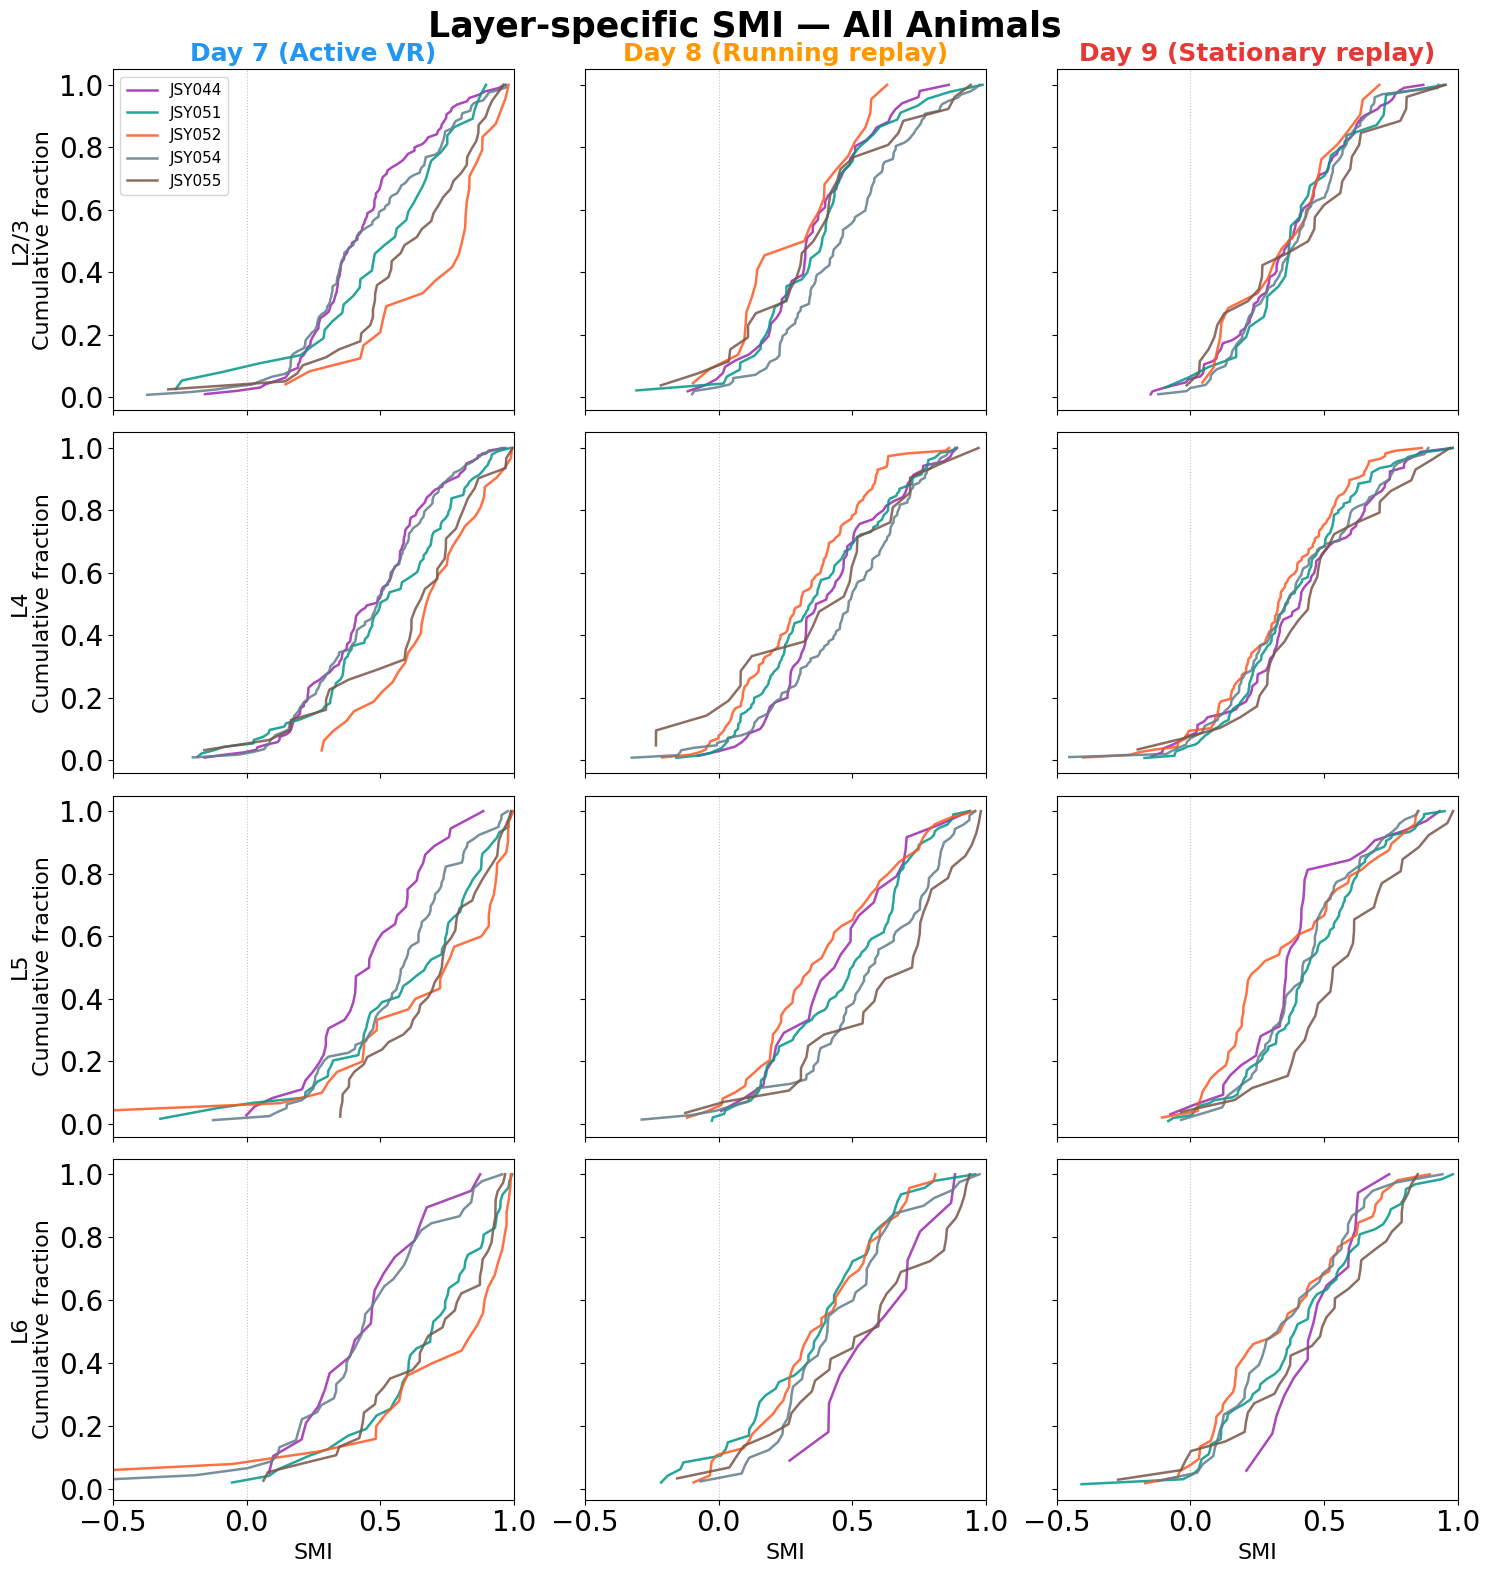

In [46]:
# --- Per-animal: 4 layers × 3 conditions grid ---
for sess in all_sessions:
    fig, axes = plt.subplots(len(LAYER_NAMES), 3,
                             figsize=(15, 4 * len(LAYER_NAMES)),
                             sharex=True, sharey='row')
    for row, layer in enumerate(LAYER_NAMES):
        for col, (cond, cond_label, cond_color) in enumerate(
                zip(['Day7', 'Day8', 'Day9'], COND_LABELS, COND_COLORS)):
            ax = axes[row, col]
            layer_data = sess[cond]['layers'].get(layer)
            if layer_data is None or len(layer_data['SMI']) == 0:
                ax.text(0.5, 0.5, 'No data', transform=ax.transAxes,
                        ha='center', va='center', fontsize=14)
            else:
                plot_cdf(ax, layer_data['SMI'], color=cond_color,
                         label=f"n={layer_data['n_valid']}")
                ax.axvline(layer_data['median_smi'], color=cond_color, lw=1.5, ls='--', alpha=0.7)
                ax.legend(fontsize=13)
            ax.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.5)
            ax.set_xlim(-0.5, 1.0)
            if row == 0:
                ax.set_title(cond_label.replace('\n', ' '), fontsize=18, fontweight='bold', color=cond_color)
            if col == 0:
                ax.set_ylabel(f'{layer}\nCumulative fraction', fontsize=16)
            if row == len(LAYER_NAMES) - 1:
                ax.set_xlabel('SMI', fontsize=16)
    fig.suptitle(f'{sess["animal_id"]} — Layer-specific SMI', fontsize=25, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(sess['output_dir'], f'Figure3_LayerCDF_{sess["animal_id"]}.png')
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved: {save_path}')
    plt.show()


# --- Cross-animal: 4 layers × 3 conditions, one line per animal ---
fig, axes = plt.subplots(len(LAYER_NAMES), 3,
                         figsize=(15, 4 * len(LAYER_NAMES)),
                         sharex=True, sharey='row')

for row, layer in enumerate(LAYER_NAMES):
    for col, (cond, cond_label, cond_color) in enumerate(
            zip(['Day7', 'Day8', 'Day9'], COND_LABELS, COND_COLORS)):
        ax = axes[row, col]
        for sess, anim_color in zip(all_sessions, ANIMAL_COLORS):
            layer_data = sess[cond]['layers'].get(layer)
            if layer_data is not None and len(layer_data['SMI']) > 0:
                plot_cdf(ax, layer_data['SMI'], color=anim_color, lw=1.8,
                         label=sess['animal_id'], alpha=0.85)
        ax.axvline(0, color='gray', lw=0.8, ls=':', alpha=0.5)
        ax.set_xlim(-0.5, 1.0)
        if row == 0:
            ax.set_title(cond_label.replace('\n', ' '), fontsize=18, fontweight='bold', color=cond_color)
            if col == 0:
                ax.legend(fontsize=11, loc='upper left')
        if col == 0:
            ax.set_ylabel(f'{layer}\nCumulative fraction', fontsize=16)
        if row == len(LAYER_NAMES) - 1:
            ax.set_xlabel('SMI', fontsize=16)

fig.suptitle('Layer-specific SMI — All Animals', fontsize=25, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(ACROSS_ANIMALS_DIR, 'Figure3_LayerCDF_AllAnimals.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()

---
## Layer-specific statistics

In [47]:
print('='*70)
print('LAYER-SPECIFIC STATISTICS')
print('='*70)

for sess in all_sessions:
    print(f'\n{sess["animal_id"]}')
    for layer in LAYER_NAMES:
        print(f'\n  {layer}')
        for cond in ['Day7', 'Day8', 'Day9']:
            ld = sess[cond]['layers'].get(layer)
            if ld is None:
                print(f'    {cond}: no data')
            else:
                mad = float(stats.median_abs_deviation(ld['SMI'])) if len(ld['SMI']) > 0 else np.nan
                print(f'    {cond}: median={np.median(ld["SMI"]):.3f} ± {mad:.3f} (MAD), n={len(ld["SMI"])}')

        # Mann-Whitney U (unpaired) — cells are NOT tracked across sessions.
        for cond_a, cond_b in [('Day7', 'Day8'), ('Day7', 'Day9')]:
            ld_a = sess[cond_a]['layers'].get(layer)
            ld_b = sess[cond_b]['layers'].get(layer)
            if ld_a is None or ld_b is None:
                print(f'    {cond_a} vs {cond_b}: no layer data')
                continue
            smi_a = ld_a['SMI']
            smi_b = ld_b['SMI']
            if len(smi_a) < 2 or len(smi_b) < 2:
                print(f'    {cond_a} vs {cond_b}: insufficient data (n_a={len(smi_a)}, n_b={len(smi_b)})')
                continue
            stat_w, p = stats.mannwhitneyu(smi_a, smi_b, alternative='two-sided')
            print(f'    {cond_a} vs {cond_b}: n_a={len(smi_a)}, n_b={len(smi_b)}, U={stat_w:.1f}, p={p:.4f}')

LAYER-SPECIFIC STATISTICS

JSY044

  L2/3
    Day7: median=0.414 ± 0.142 (MAD), n=95
    Day8: median=0.331 ± 0.137 (MAD), n=51
    Day9: median=0.373 ± 0.149 (MAD), n=104
    Day7 vs Day8: n_a=95, n_b=51, U=2903.0, p=0.0488
    Day7 vs Day9: n_a=95, n_b=104, U=5665.0, p=0.0742

  L4
    Day7: median=0.487 ± 0.154 (MAD), n=121
    Day8: median=0.384 ± 0.122 (MAD), n=70
    Day9: median=0.409 ± 0.182 (MAD), n=80
    Day7 vs Day8: n_a=121, n_b=70, U=4736.0, p=0.1740
    Day7 vs Day9: n_a=121, n_b=80, U=5304.0, p=0.2509

  L5
    Day7: median=0.459 ± 0.162 (MAD), n=36
    Day8: median=0.445 ± 0.210 (MAD), n=24
    Day9: median=0.359 ± 0.073 (MAD), n=32
    Day7 vs Day8: n_a=36, n_b=24, U=456.0, p=0.7229
    Day7 vs Day9: n_a=36, n_b=32, U=700.0, p=0.1292

  L6
    Day7: median=0.465 ± 0.172 (MAD), n=19
    Day8: median=0.616 ± 0.162 (MAD), n=11
    Day9: median=0.460 ± 0.132 (MAD), n=17
    Day7 vs Day8: n_a=19, n_b=11, U=63.0, p=0.0776
    Day7 vs Day9: n_a=19, n_b=17, U=152.0, p=0.7755


---
## Figure 4 — SMI reduction by layer (violin plots)
Key prediction: deep layers (L5/L6) show larger SMI reduction in replay conditions.

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\OpenLoopVR_Analysis_day7\Figure4_SMI_by_Layer_JSY044.png


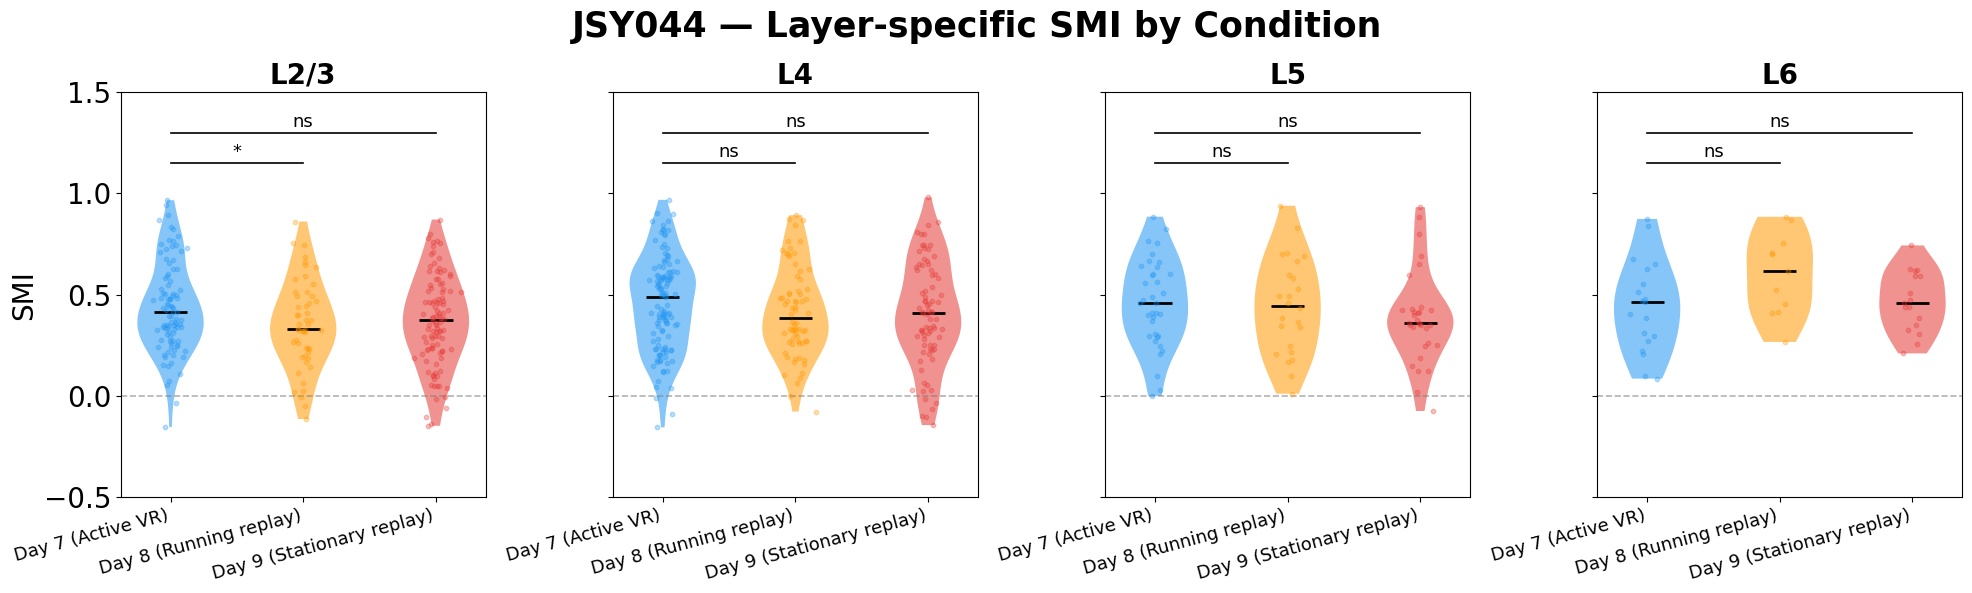

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\OpenLoopVR_Analysis_day4\Figure4_SMI_by_Layer_JSY051.png


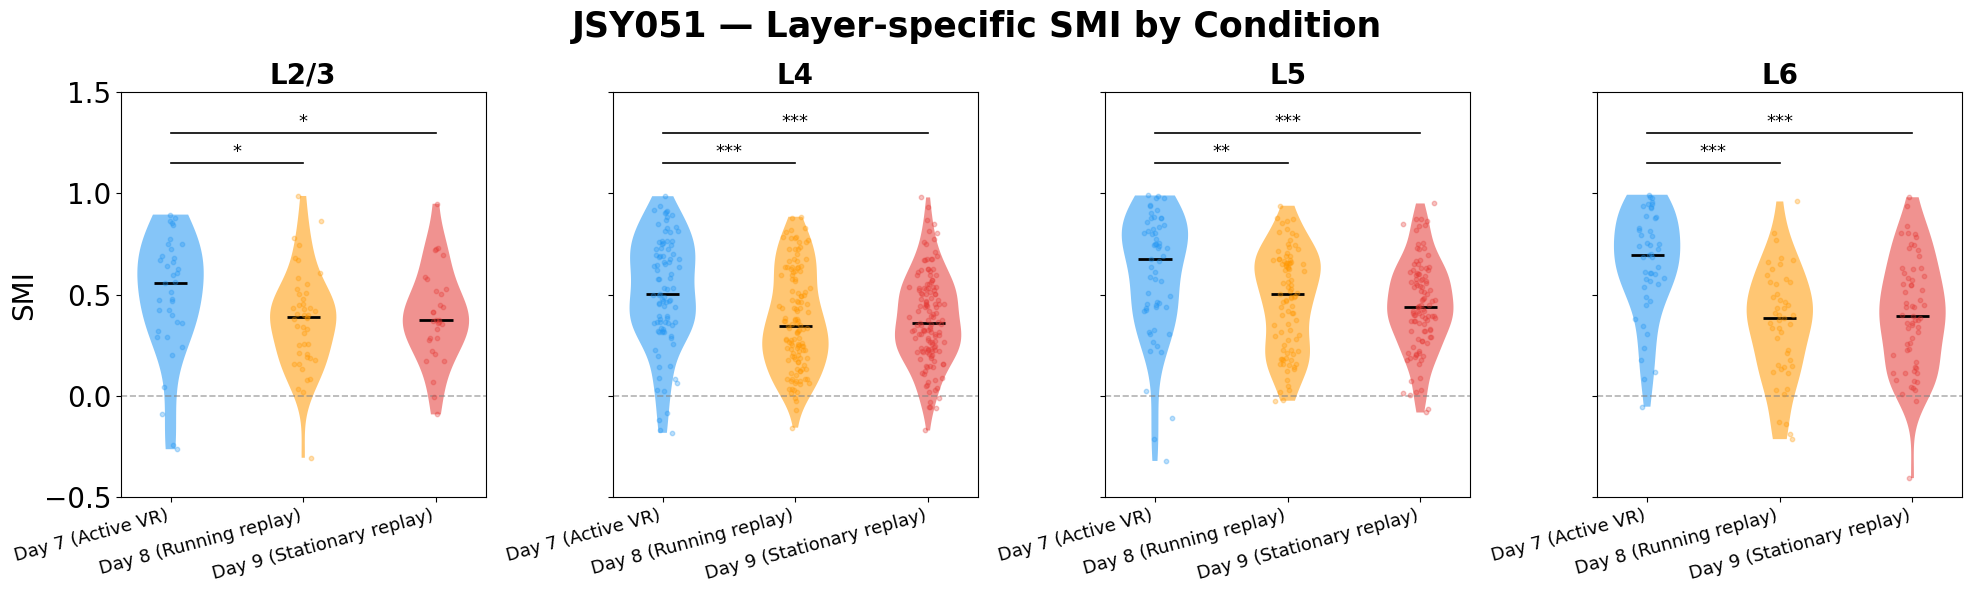

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\OpenLoopVR_Analysis_day7\Figure4_SMI_by_Layer_JSY052.png


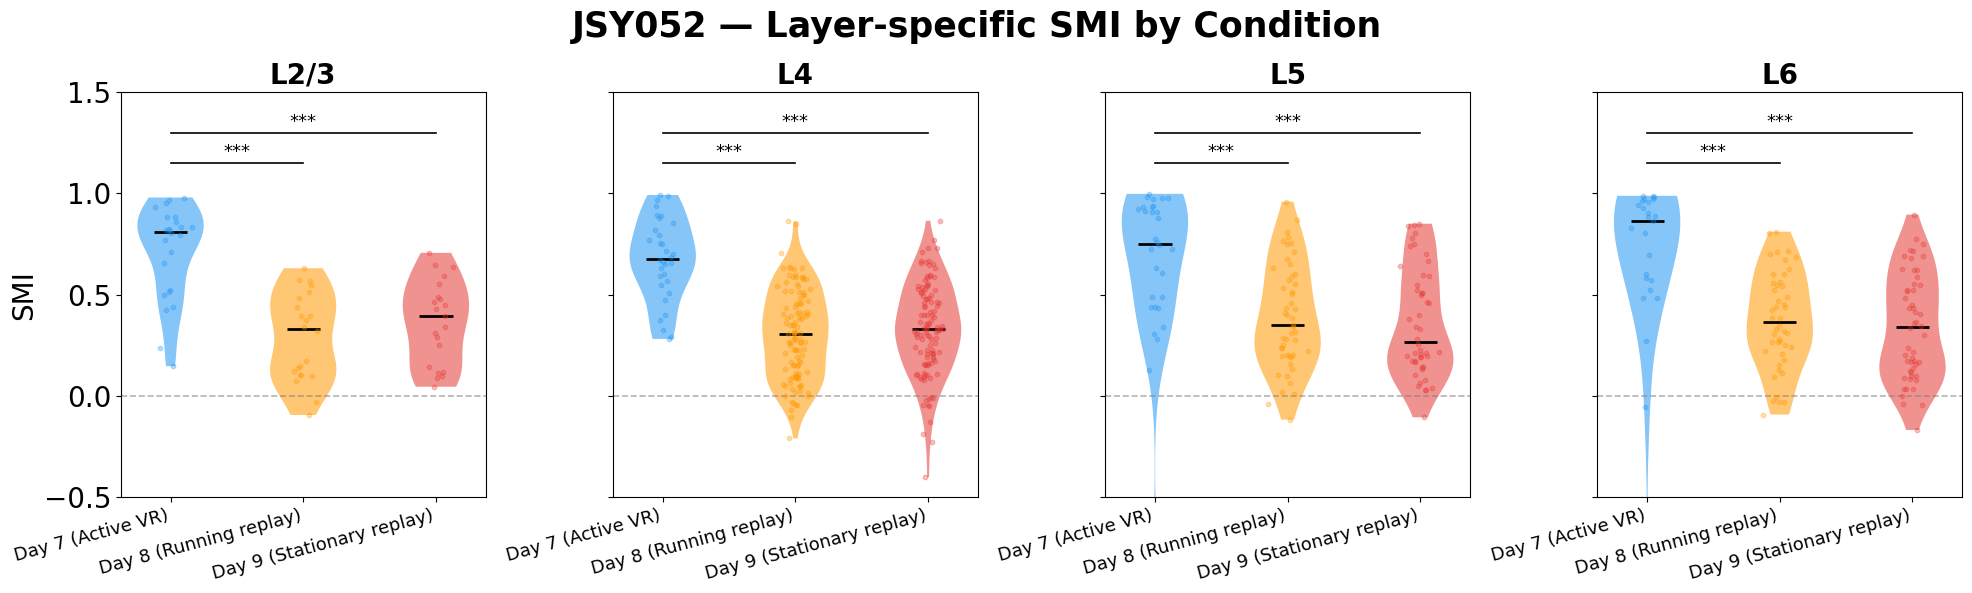

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\OpenLoopVR_Analysis_day7\Figure4_SMI_by_Layer_JSY054.png


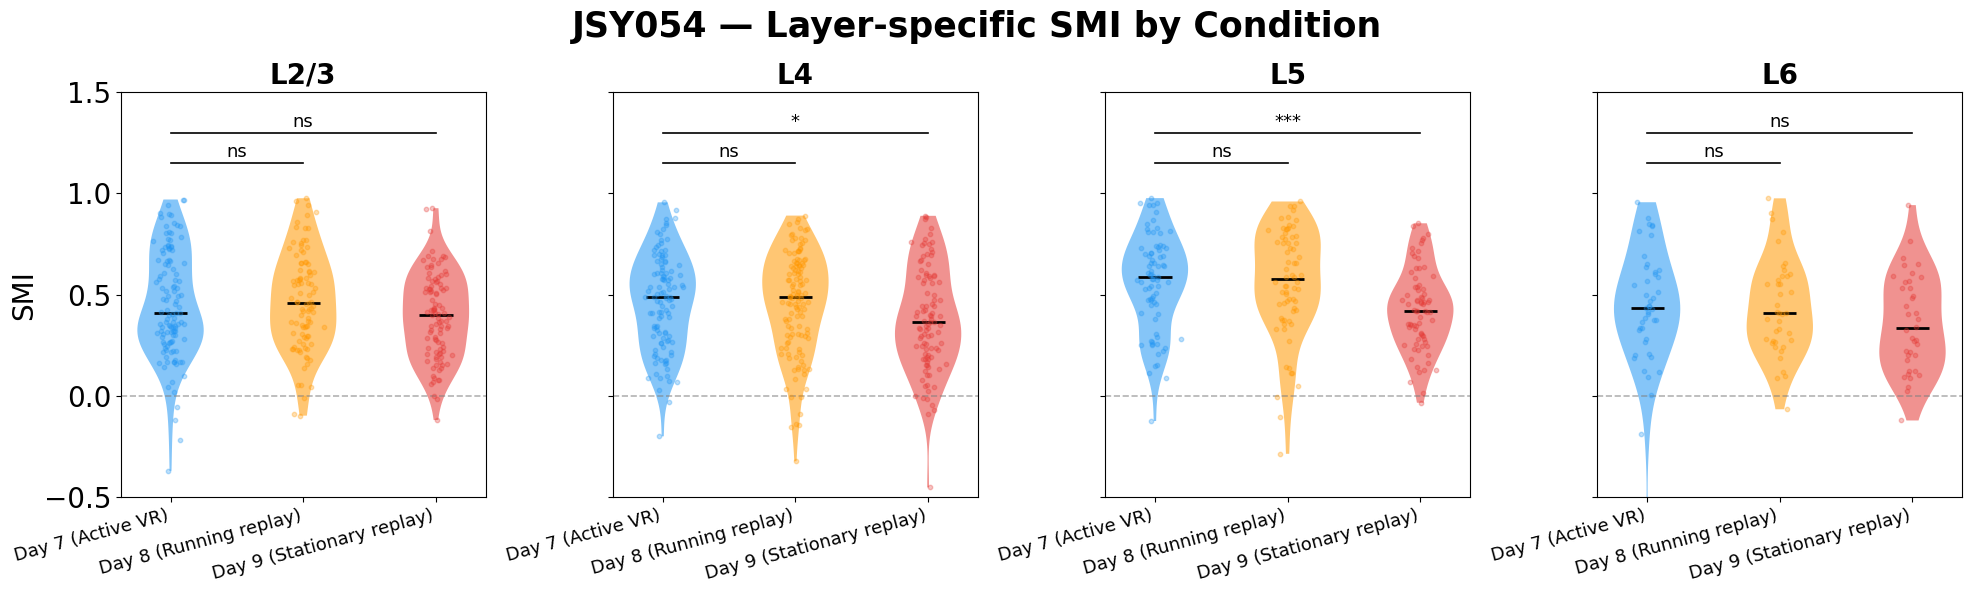

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\OpenLoopVR_Analysis_day7\Figure4_SMI_by_Layer_JSY055.png


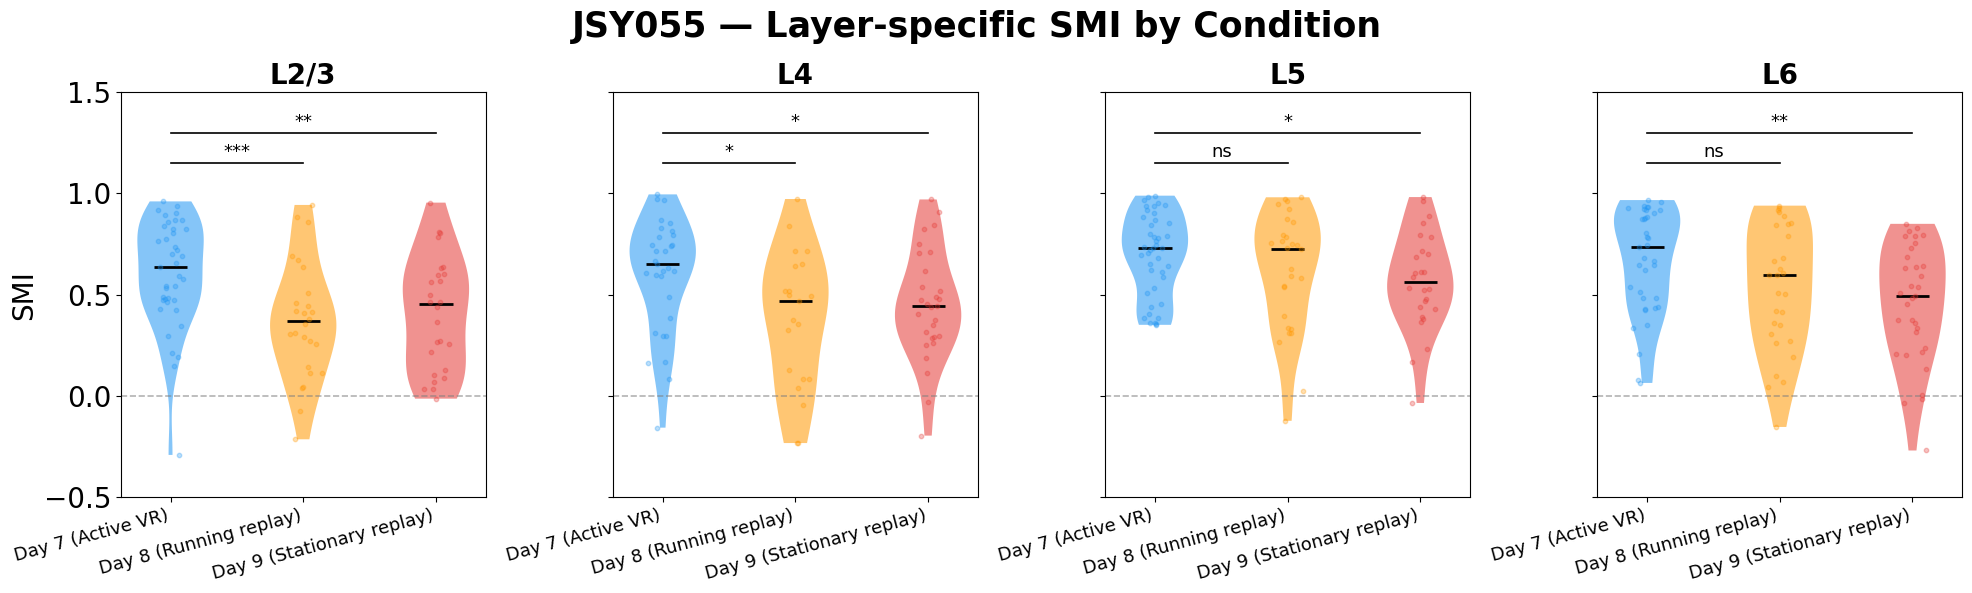

Saved: D:\V1_SpatialModulation\2p\V1_prism\across_animals_OpenLoopVR_Analysis\Figure4_SMI_by_Layer_AllAnimals.png


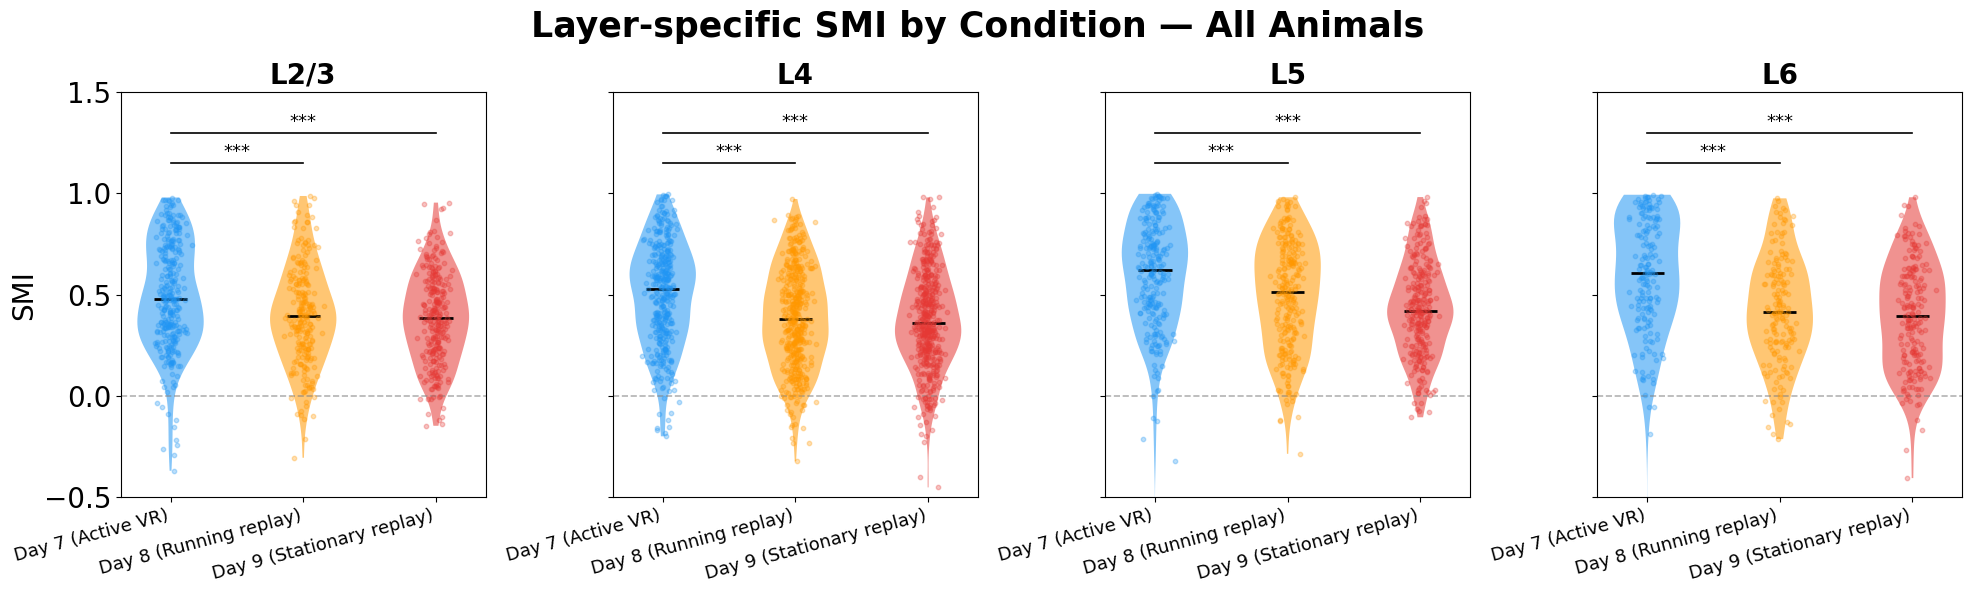

In [48]:
def _violin_layer_fig(data_by_layer, title, save_path):
    """Plot per-layer SMI violin for one dataset (per-animal or pooled)."""
    fig, axes = plt.subplots(1, len(LAYER_NAMES), figsize=(5 * len(LAYER_NAMES), 6), sharey=True)
    for ax, layer, layer_color in zip(axes, LAYER_NAMES, LAYER_COLORS):
        pooled = data_by_layer[layer]
        data_to_plot  = [np.array(pooled[c]) for c in ['Day7', 'Day8', 'Day9']]
        valid_mask    = [len(d) > 1 for d in data_to_plot]
        data_filtered = [d for d, v in zip(data_to_plot, valid_mask) if v]
        colors_filt   = [c for c, v in zip(COND_COLORS, valid_mask) if v]
        labels_filt   = [l for l, v in zip(COND_LABELS, valid_mask) if v]

        if data_filtered:
            parts = ax.violinplot(data_filtered, positions=range(len(data_filtered)),
                                  showmedians=True, showextrema=False)
            for pc, color in zip(parts['bodies'], colors_filt):
                pc.set_facecolor(color); pc.set_alpha(0.55)
            parts['cmedians'].set_color('k'); parts['cmedians'].set_linewidth(2)
            for i, (d, color) in enumerate(zip(data_filtered, colors_filt)):
                ax.scatter(np.random.normal(i, 0.05, size=len(d)), d,
                           s=10, alpha=0.3, color=color, zorder=3)

            y_max = 1.1
            offset = 0.0
            for other_idx in [1, 2]:
                if not valid_mask[0] or not valid_mask[other_idx]:
                    continue
                _, p = stats.mannwhitneyu(np.array(pooled['Day7']),
                                          np.array(pooled[['Day8', 'Day9'][other_idx - 1]]),
                                          alternative='two-sided')
                sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
                bar_y = y_max + 0.05 + offset
                ax.plot([0, other_idx], [bar_y, bar_y], 'k-', lw=1.2)
                ax.text((other_idx) / 2, bar_y + 0.01, sig, ha='center', va='bottom', fontsize=13)
                offset += 0.15

        ax.set_ylim(-0.5, 1.5)
        ax.axhline(0, color='gray', lw=1.2, ls='--', alpha=0.6)
        ax.set_xticks(range(len(labels_filt)))
        ax.set_xticklabels([l.replace('\n', ' ') for l in labels_filt], fontsize=13, rotation=15, ha='right')
        ax.set_title(layer, fontsize=20, fontweight='bold')
        if ax == axes[0]:
            ax.set_ylabel('SMI')

    fig.suptitle(title, fontsize=25, fontweight='bold')
    plt.tight_layout()
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved: {save_path}')
    plt.show()


# --- Per-animal ---
for sess in all_sessions:
    data_by_layer = {
        layer: {cond: (sess[cond]['layers'][layer]['SMI'].tolist()
                        if layer in sess[cond]['layers'] else [])
                for cond in ['Day7', 'Day8', 'Day9']}
        for layer in LAYER_NAMES
    }
    _violin_layer_fig(
        data_by_layer,
        title=f'{sess["animal_id"]} — Layer-specific SMI by Condition',
        save_path=os.path.join(sess['output_dir'],
                               f'Figure4_SMI_by_Layer_{sess["animal_id"]}.png')
    )

# --- Cross-animal: pool all animals ---
pooled_by_layer = {
    layer: {cond: [] for cond in ['Day7', 'Day8', 'Day9']}
    for layer in LAYER_NAMES
}
for sess in all_sessions:
    for layer in LAYER_NAMES:
        for cond in ['Day7', 'Day8', 'Day9']:
            ld = sess[cond]['layers'].get(layer)
            if ld is not None and len(ld['SMI']) > 0:
                pooled_by_layer[layer][cond].extend(ld['SMI'].tolist())

_violin_layer_fig(
    pooled_by_layer,
    title='Layer-specific SMI by Condition — All Animals',
    save_path=os.path.join(ACROSS_ANIMALS_DIR, 'Figure4_SMI_by_Layer_AllAnimals.png')
)

---
## Figure 5 — SMI Reduction Magnitude by Layer
For each animal × layer, compute the difference in median SMI between conditions:
1. **Active VR − Running Replay** (Day7 − Day8)
2. **Active VR − Stationary Replay** (Day7 − Day9)
3. **Running Replay − Stationary Replay** (Day8 − Day9)

Each dot = one animal. Bar = mean ± SEM across animals.
Key question: which layer shows the largest reduction in each contrast?

Reductions computed.

Active VR − Running Replay
  L2/3: [ 0.083  0.166  0.481 -0.048  0.269]  mean=0.190
  L4: [0.103 0.155 0.37  0.003 0.183]  mean=0.163
  L5: [0.014 0.171 0.403 0.013 0.006]  mean=0.121
  L6: [-0.151  0.309  0.497  0.025  0.135]  mean=0.163

Active VR − Stationary Replay
  L2/3: [0.041 0.182 0.419 0.009 0.185]  mean=0.167
  L4: [0.078 0.144 0.349 0.125 0.208]  mean=0.181
  L5: [0.099 0.234 0.486 0.168 0.17 ]  mean=0.231
  L6: [0.005 0.301 0.523 0.1   0.24 ]  mean=0.234

Running Replay − Stationary Replay
  L2/3: [-0.042  0.016 -0.062  0.056 -0.084]  mean=-0.023
  L4: [-0.026 -0.011 -0.021  0.122  0.025]  mean=0.018
  L5: [0.085 0.063 0.082 0.155 0.165]  mean=0.110
  L6: [ 0.156 -0.008  0.025  0.075  0.106]  mean=0.071

Saved: D:\V1_SpatialModulation\2p\V1_prism\across_animals_OpenLoopVR_Analysis\Figure5_SMI_Reduction_by_Layer_55 excluded.png


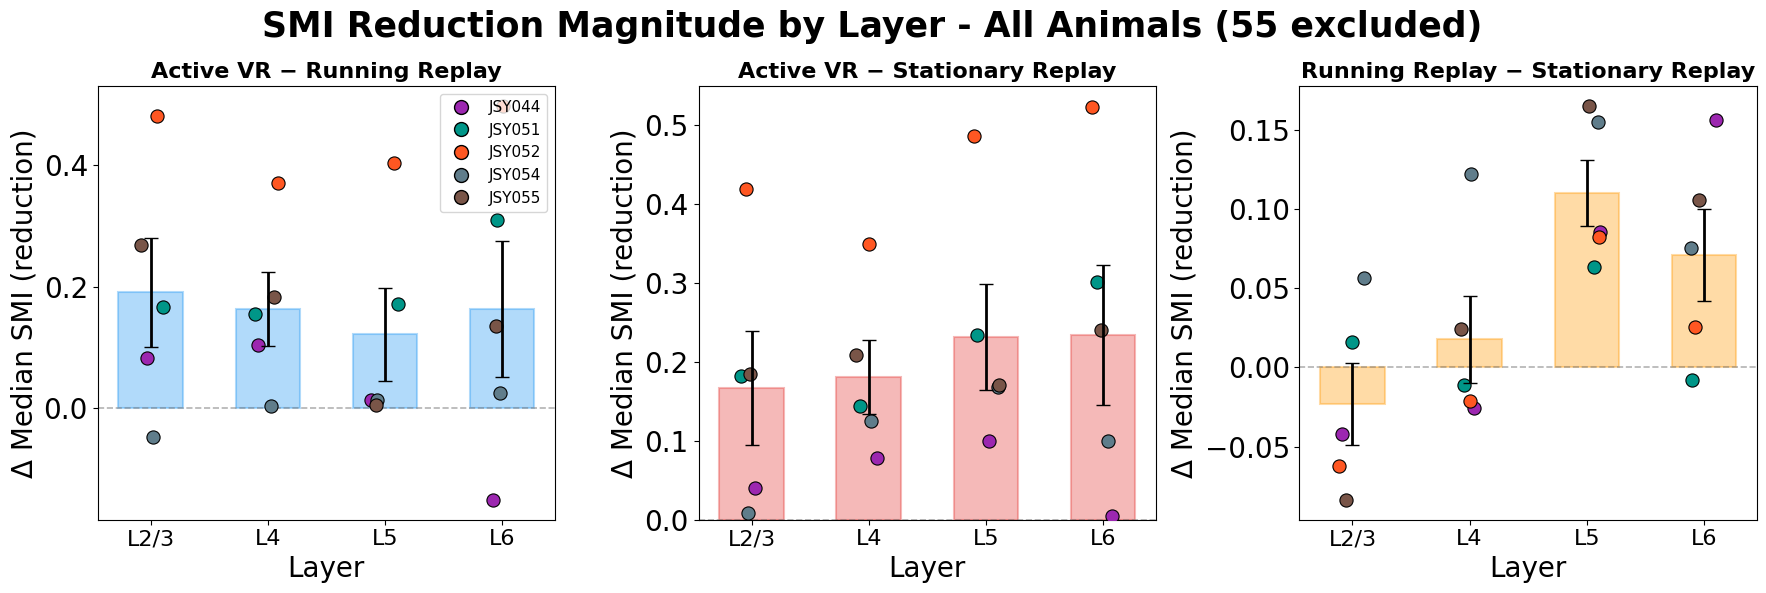

In [49]:
CONTRASTS = [
    ('Day7', 'Day8', 'Active VR − Running Replay',         '#2196F3'),
    ('Day7', 'Day9', 'Active VR − Stationary Replay',      '#E53935'),
    ('Day8', 'Day9', 'Running Replay − Stationary Replay', '#FF9800'),
]

# Per-animal, per-layer reduction = median(cond_a) - median(cond_b)
reductions = {}
for cond_a, cond_b, label, _ in CONTRASTS:
    reductions[label] = {}
    for layer in LAYER_NAMES:
        vals = []
        for sess in all_sessions:
            ld_a = sess[cond_a]['layers'].get(layer)
            ld_b = sess[cond_b]['layers'].get(layer)
            if (ld_a is not None and len(ld_a['SMI']) > 0
                    and ld_b is not None and len(ld_b['SMI']) > 0):
                vals.append(np.median(ld_a['SMI']) - np.median(ld_b['SMI']))
            else:
                vals.append(np.nan)
        reductions[label][layer] = np.array(vals)

print('Reductions computed.')
for _, _, label, _ in CONTRASTS:
    print(f'\n{label}')
    for layer in LAYER_NAMES:
        v = reductions[label][layer]
        valid = v[~np.isnan(v)]
        print(f'  {layer}: {np.round(valid, 3)}  mean={np.nanmean(v):.3f}')

# --- Figure ---
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (cond_a, cond_b, label, contrast_color) in zip(axes, CONTRASTS):
    x = np.arange(len(LAYER_NAMES))

    for i, layer in enumerate(LAYER_NAMES):
        vals       = reductions[label][layer]
        valid_mask = ~np.isnan(vals)
        valid_vals = vals[valid_mask]
        valid_colors = [c for c, m in zip(ANIMAL_COLORS[:len(all_sessions)], valid_mask) if m]

        if len(valid_vals) == 0:
            continue

        mean_v = np.mean(valid_vals)
        sem_v  = np.std(valid_vals, ddof=1) / np.sqrt(len(valid_vals)) if len(valid_vals) > 1 else 0

        ax.bar(i, mean_v, width=0.55, color=contrast_color, alpha=0.35,
               edgecolor=contrast_color, linewidth=1.5, zorder=2)
        ax.errorbar(i, mean_v, yerr=sem_v, fmt='none', color='k', capsize=5, lw=2, zorder=6)

        jitter = np.random.uniform(-0.12, 0.12, size=len(valid_vals))
        for jx, (v, anim_color) in enumerate(zip(valid_vals, valid_colors)):
            ax.scatter(i + jitter[jx], v, s=90, color=anim_color,
                       zorder=5, edgecolors='k', linewidths=0.8)

    ax.axhline(0, color='gray', lw=1.2, ls='--', alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(LAYER_NAMES, fontsize=16)
    ax.set_xlabel('Layer')
    ax.set_ylabel('Δ Median SMI (reduction)')
    ax.set_title(label, fontsize=16, fontweight='bold')

handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c,
               markeredgecolor='k', markersize=10, label=s['animal_id'])
    for c, s in zip(ANIMAL_COLORS[:len(all_sessions)], all_sessions)
]
axes[0].legend(handles=handles, fontsize=11, loc='best')

fig.suptitle('SMI Reduction Magnitude by Layer - All Animals (55 excluded)', fontsize=25, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(ACROSS_ANIMALS_DIR, 'Figure5_SMI_Reduction_by_Layer_55 excluded.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'\nSaved: {save_path}')
plt.show()

In [50]:
print('='*70)
print('SMI REDUCTION STATISTICS')
print('n per cell = animals with valid data for that layer × contrast')
print('='*70)

for cond_a, cond_b, label, _ in CONTRASTS:
    print(f'\n--- {label} ---')

    layer_valid_vals = []
    for layer in LAYER_NAMES:
        v     = reductions[label][layer]
        valid = v[~np.isnan(v)]
        layer_valid_vals.append(valid)
        n     = len(valid)
        mean_r = np.mean(valid) if n > 0 else np.nan
        sem_r  = np.std(valid, ddof=1) / np.sqrt(n) if n > 1 else np.nan

        if n >= 3:
            try:
                w_stat, p_w = stats.wilcoxon(valid, alternative='greater')
                sig = '***' if p_w < 0.001 else ('**' if p_w < 0.01 else ('*' if p_w < 0.05 else 'ns'))
                print(f'  {layer}: mean Δ={mean_r:.3f} ± {sem_r:.3f} SEM, n={n}, '
                      f'Wilcoxon vs 0 (>0): W={w_stat:.1f}, p={p_w:.4f} {sig}')
            except Exception as e:
                print(f'  {layer}: mean Δ={mean_r:.3f}, n={n}  [Wilcoxon error: {e}]')
        else:
            print(f'  {layer}: mean Δ={mean_r:.3f}, n={n} (too few animals for test)')

    # Kruskal-Wallis across layers — does reduction magnitude differ by layer?
    groups = [(v, ln) for v, ln in zip(layer_valid_vals, LAYER_NAMES) if len(v) >= 2]
    if len(groups) >= 2:
        kw_stat, kw_p = stats.kruskal(*[v for v, _ in groups])
        sig_kw = '***' if kw_p < 0.001 else ('**' if kw_p < 0.01 else ('*' if kw_p < 0.05 else 'ns'))
        print(f'\n  Kruskal-Wallis across layers: H={kw_stat:.3f}, p={kw_p:.4f} {sig_kw}')

        # Pairwise Mann-Whitney U with Bonferroni correction
        pairs = [(i, j) for i in range(len(groups)) for j in range(i + 1, len(groups))]
        for i, j in pairs:
            v_i, ln_i = groups[i]
            v_j, ln_j = groups[j]
            if len(v_i) >= 2 and len(v_j) >= 2:
                u_stat, p_raw = stats.mannwhitneyu(v_i, v_j, alternative='two-sided')
                p_corr = min(p_raw * len(pairs), 1.0)
                sig_p  = '***' if p_corr < 0.001 else ('**' if p_corr < 0.01 else ('*' if p_corr < 0.05 else 'ns'))
                print(f'    {ln_i} vs {ln_j}: U={u_stat:.1f}, p={p_raw:.4f} → Bonf. p={p_corr:.4f} {sig_p}')

SMI REDUCTION STATISTICS
n per cell = animals with valid data for that layer × contrast

--- Active VR − Running Replay ---
  L2/3: mean Δ=0.190 ± 0.089 SEM, n=5, Wilcoxon vs 0 (>0): W=14.0, p=0.0625 ns
  L4: mean Δ=0.163 ± 0.060 SEM, n=5, Wilcoxon vs 0 (>0): W=15.0, p=0.0312 *
  L5: mean Δ=0.121 ± 0.077 SEM, n=5, Wilcoxon vs 0 (>0): W=15.0, p=0.0312 *
  L6: mean Δ=0.163 ± 0.112 SEM, n=5, Wilcoxon vs 0 (>0): W=12.0, p=0.1562 ns

  Kruskal-Wallis across layers: H=0.337, p=0.9529 ns
    L2/3 vs L4: U=13.0, p=1.0000 → Bonf. p=1.0000 ns
    L2/3 vs L5: U=15.0, p=0.6905 → Bonf. p=1.0000 ns
    L2/3 vs L6: U=13.0, p=1.0000 → Bonf. p=1.0000 ns
    L4 vs L5: U=14.0, p=0.8413 → Bonf. p=1.0000 ns
    L4 vs L6: U=13.0, p=1.0000 → Bonf. p=1.0000 ns
    L5 vs L6: U=10.0, p=0.6905 → Bonf. p=1.0000 ns

--- Active VR − Stationary Replay ---
  L2/3: mean Δ=0.167 ± 0.072 SEM, n=5, Wilcoxon vs 0 (>0): W=15.0, p=0.0312 *
  L4: mean Δ=0.181 ± 0.047 SEM, n=5, Wilcoxon vs 0 (>0): W=15.0, p=0.0312 *
  L5: mea

---
## Figure 5 — Summary statistics table

In [51]:
import pandas as pd

rows = []
for sess in all_sessions:
    for layer in ['ALL'] + LAYER_NAMES:
        for cond in ['Day7', 'Day8', 'Day9']:
            if layer == 'ALL':
                smi_arr = sess[cond]['SMI']
                n       = sess[cond]['n_valid']
            else:
                ld = sess[cond]['layers'].get(layer)
                smi_arr = ld['SMI'] if ld else np.array([])
                n       = len(smi_arr)

            if n > 0:
                median = np.median(smi_arr)
                mad    = float(stats.median_abs_deviation(smi_arr))
            else:
                median = mad = np.nan

            rows.append({
                'Animal'    : sess['animal_id'],
                'Layer'     : layer,
                'Condition' : cond,
                'N cells'   : n,
                'Median SMI': round(median, 3) if not np.isnan(median) else 'n/a',
                'MAD'       : round(mad,    3) if not np.isnan(mad)    else 'n/a',
            })

df = pd.DataFrame(rows)
pd.set_option('display.max_rows', 200)
display(df)

# Per-animal CSVs
for sess in all_sessions:
    df_anim = df[df['Animal'] == sess['animal_id']]
    csv_path = os.path.join(sess['output_dir'],
                            f'Figure5_SummaryStats_{sess["animal_id"]}.csv')
    df_anim.to_csv(csv_path, index=False)
    print(f'Saved: {csv_path}')

# Cross-animal CSV
csv_path = os.path.join(ACROSS_ANIMALS_DIR, 'Figure5_SummaryStats_AllAnimals.csv')
df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')

,Animal,Layer,Condition,N cells,Median SMI,MAD
0,JSY044,ALL,Day7,271,0.434,0.162
1,JSY044,ALL,Day8,156,0.399,0.140
2,JSY044,ALL,Day9,233,0.386,0.150
3,JSY044,L2/3,Day7,95,0.414,0.142
4,JSY044,L2/3,Day8,51,0.331,0.137
5,JSY044,L2/3,Day9,104,0.373,0.149
6,JSY044,L4,Day7,121,0.487,0.154
7,JSY044,L4,Day8,70,0.384,0.122
8,JSY044,L4,Day9,80,0.409,0.182
9,JSY044,L5,Day7,36,0.459,0.162


Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\OpenLoopVR_Analysis_day7\Figure5_SummaryStats_JSY044.csv
Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\OpenLoopVR_Analysis_day4\Figure5_SummaryStats_JSY051.csv
Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\OpenLoopVR_Analysis_day7\Figure5_SummaryStats_JSY052.csv
Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\OpenLoopVR_Analysis_day7\Figure5_SummaryStats_JSY054.csv
Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\OpenLoopVR_Analysis_day7\Figure5_SummaryStats_JSY055.csv
Saved: D:\V1_SpatialModulation\2p\V1_prism\across_animals_OpenLoopVR_Analysis\Figure5_SummaryStats_AllAnimals.csv


---
## Optional — Speed comparison (VRlog vs TMlog)
Verify that animal motion (TMlog) differs between Day 8 (moving) and Day 9 (stationary).

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\OpenLoopVR_Analysis_day7\SpeedComparison_TMlog_JSY044.png


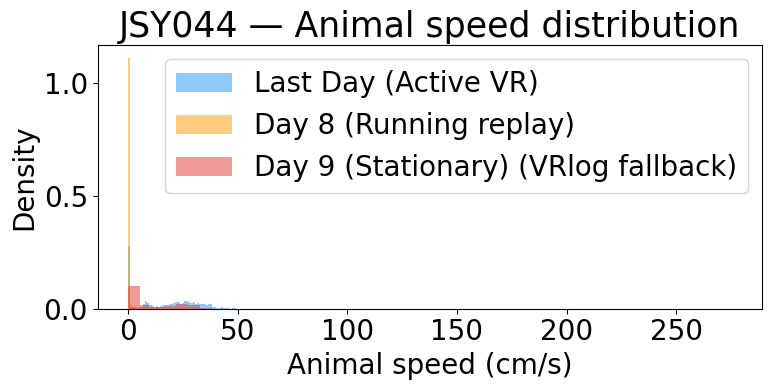

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\OpenLoopVR_Analysis_day4\SpeedComparison_TMlog_JSY051.png


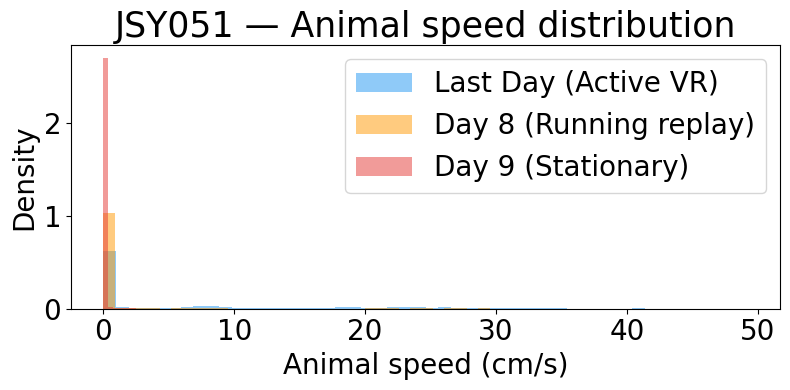

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\OpenLoopVR_Analysis_day7\SpeedComparison_TMlog_JSY052.png


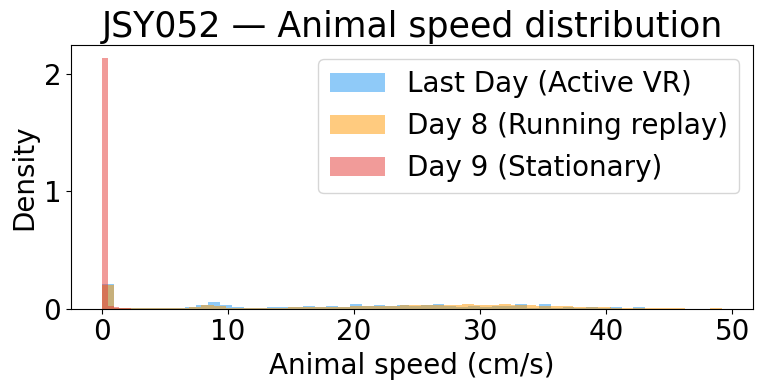

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\OpenLoopVR_Analysis_day7\SpeedComparison_TMlog_JSY054.png


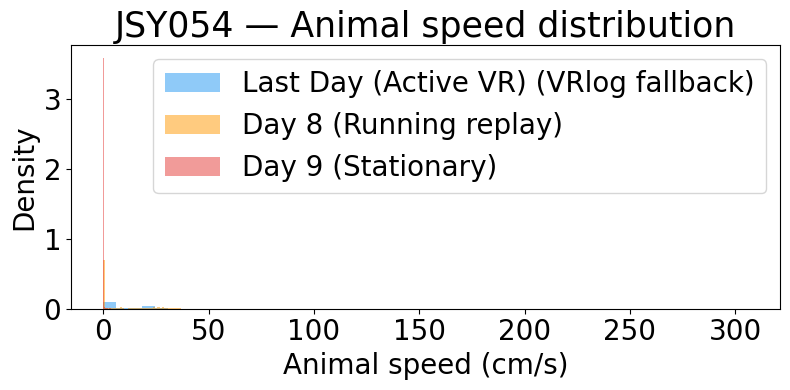

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\OpenLoopVR_Analysis_day7\SpeedComparison_TMlog_JSY055.png


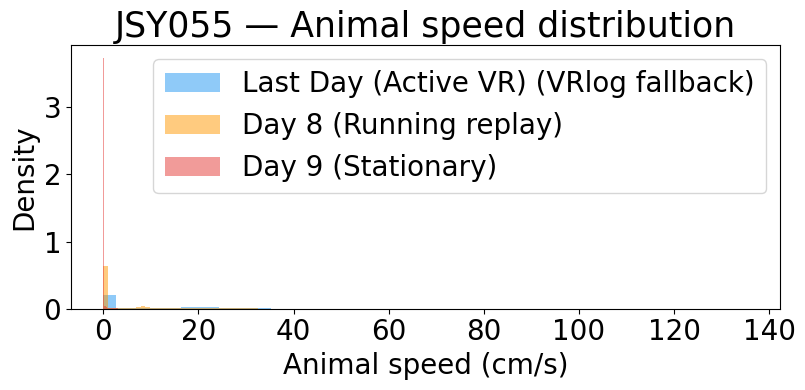

In [52]:
from helper import files as hfiles

def load_speed_from_preproc(preproc_folder):
    h5_files = glob.glob(os.path.join(preproc_folder, '*_preproc*.h5'))
    if not h5_files:
        print(f'  No *_preproc*.h5 in {preproc_folder}')
        return None
    data = hfiles.read_h5(h5_files[0])
    tmlog = data.get('speed_tmlog_cm_s')
    vr    = data.get('speed_cm_s')
    return {
        'speed_vr'    : vr,
        'speed_tmlog' : tmlog if tmlog is not None else vr,
        'has_tmlog'   : tmlog is not None,
        'session_type': data.get('session_type', 'unknown'),
    }


# --- Per-animal speed comparison ---
for sess in all_sessions:
    speed_d7 = load_speed_from_preproc(sess['lastday_preproc'])
    speed_d8 = load_speed_from_preproc(os.path.dirname(sess['openloop_active_smi']))
    speed_d9 = load_speed_from_preproc(os.path.dirname(sess['openloop_stationary_smi']))

    fig, ax = plt.subplots(figsize=(8, 4))
    for speed_dict, label, color in [
        (speed_d7, 'Last Day (Active VR)',   COND_COLORS[0]),
        (speed_d8, 'Day 8 (Running replay)', COND_COLORS[1]),
        (speed_d9, 'Day 9 (Stationary)',     COND_COLORS[2]),
    ]:
        if speed_dict and speed_dict['speed_tmlog'] is not None:
            suffix = '' if speed_dict['has_tmlog'] else ' (VRlog fallback)'
            ax.hist(speed_dict['speed_tmlog'], bins=50, alpha=0.5,
                    color=color, label=label + suffix, density=True)

    ax.set_xlabel('Animal speed (cm/s)')
    ax.set_ylabel('Density')
    ax.set_title(f'{sess["animal_id"]} — Animal speed distribution')
    ax.legend()
    plt.tight_layout()
    save_path = os.path.join(sess['output_dir'],
                             f'SpeedComparison_TMlog_{sess["animal_id"]}.png')
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved: {save_path}')
    plt.show()

---
## Confound Check 1 — Activity level per layer
Verify that mean spike rate does not drop in replay conditions (ruling out SNR as explanation for SMI reduction).

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\OpenLoopVR_Analysis_day7\ConfoundCheck1_Activity_JSY044.png


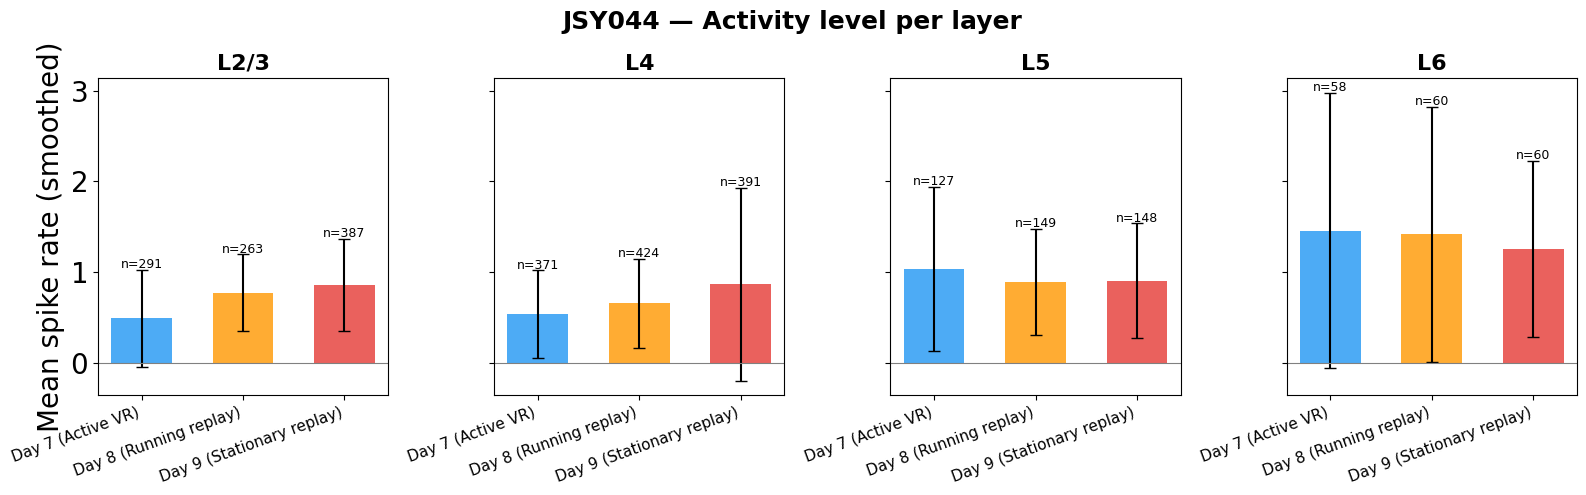

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\OpenLoopVR_Analysis_day4\ConfoundCheck1_Activity_JSY051.png


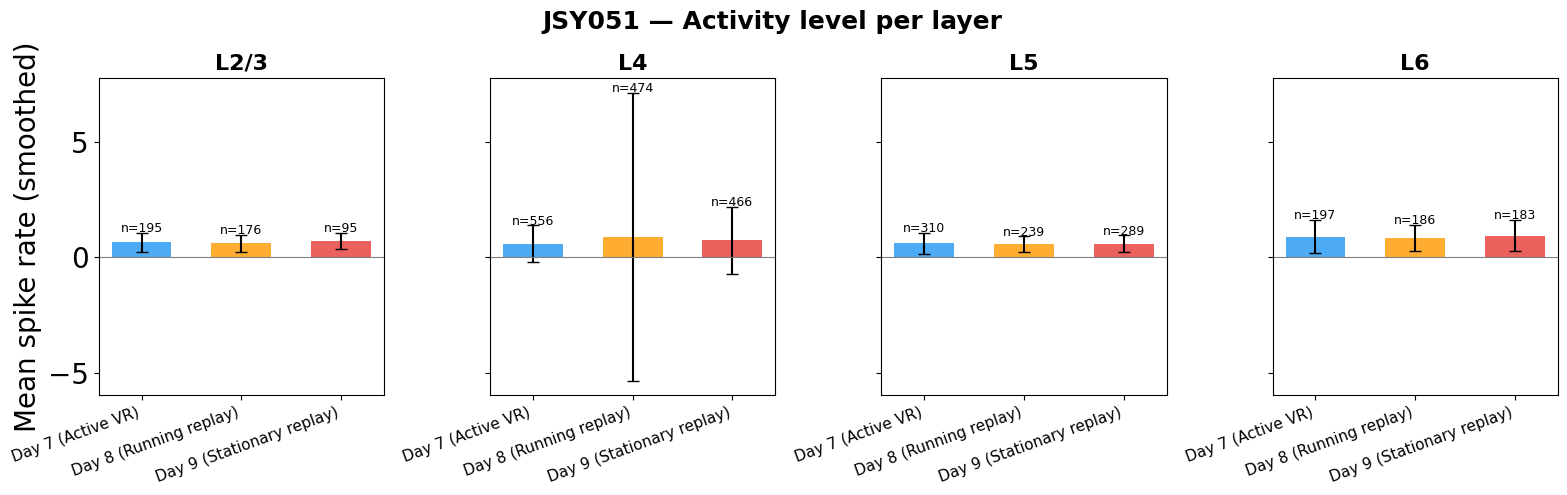

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\OpenLoopVR_Analysis_day7\ConfoundCheck1_Activity_JSY052.png


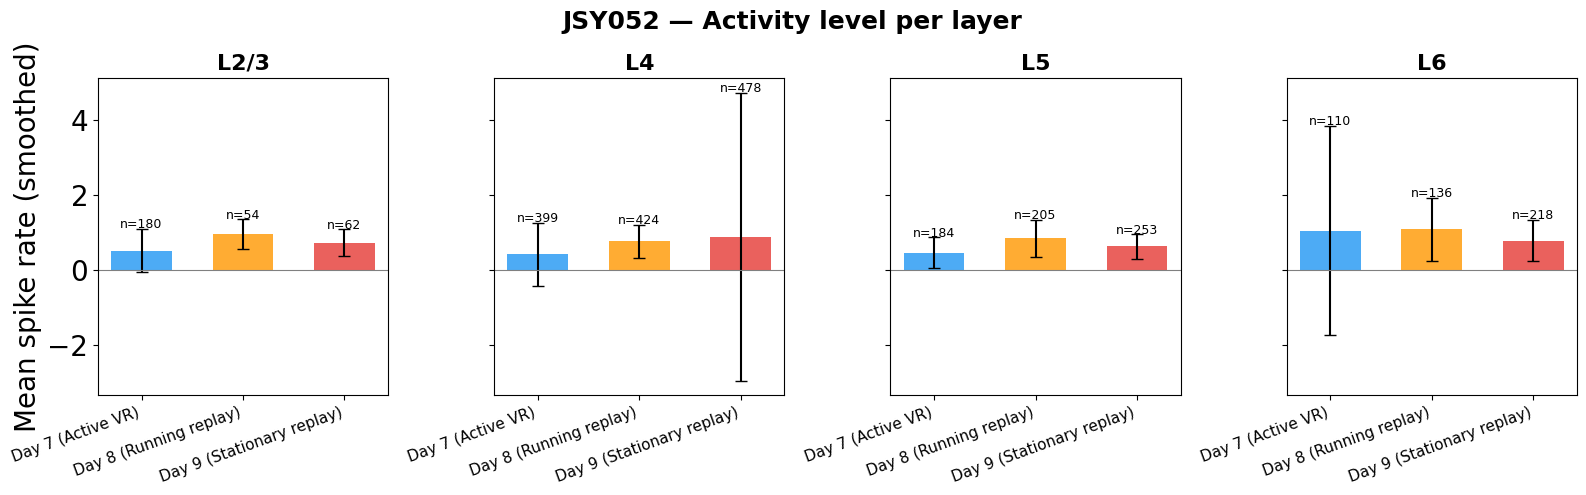

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\OpenLoopVR_Analysis_day7\ConfoundCheck1_Activity_JSY054.png


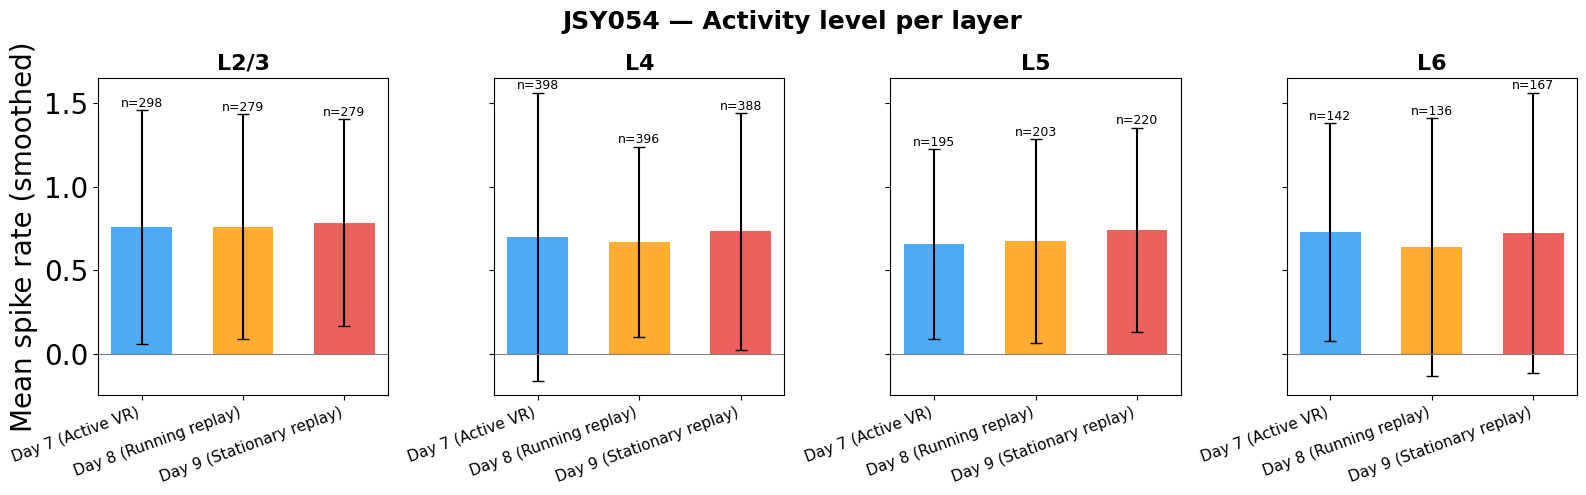

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\OpenLoopVR_Analysis_day7\ConfoundCheck1_Activity_JSY055.png


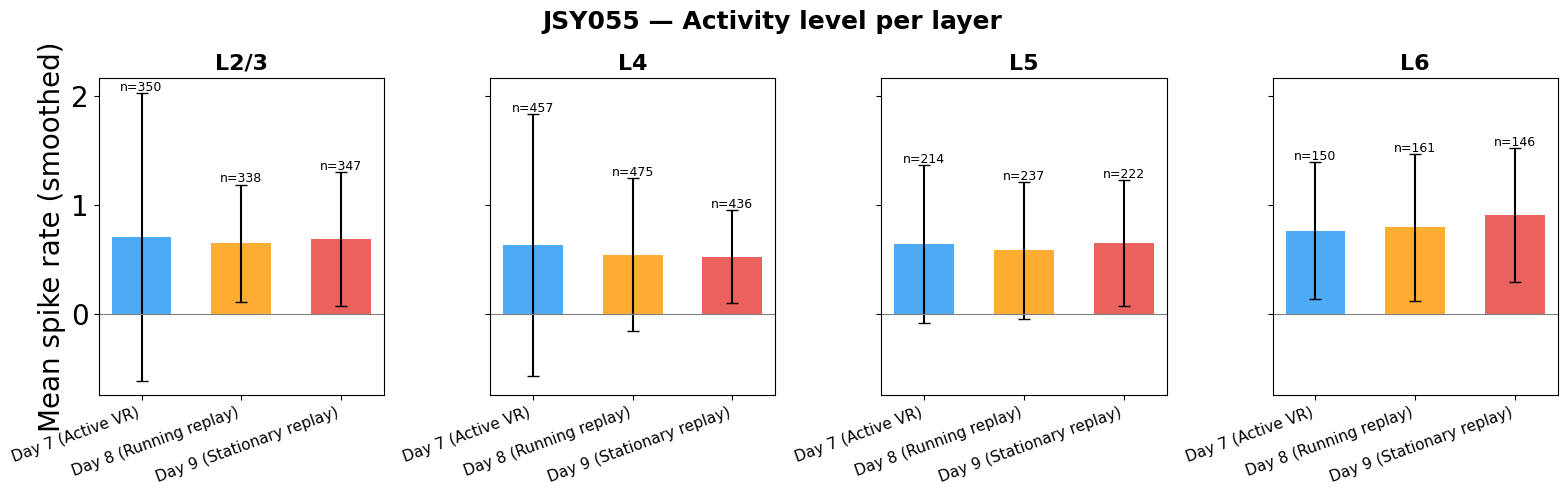

Saved: D:\V1_SpatialModulation\2p\V1_prism\across_animals_OpenLoopVR_Analysis\ConfoundCheck1_Activity_AllAnimals.png


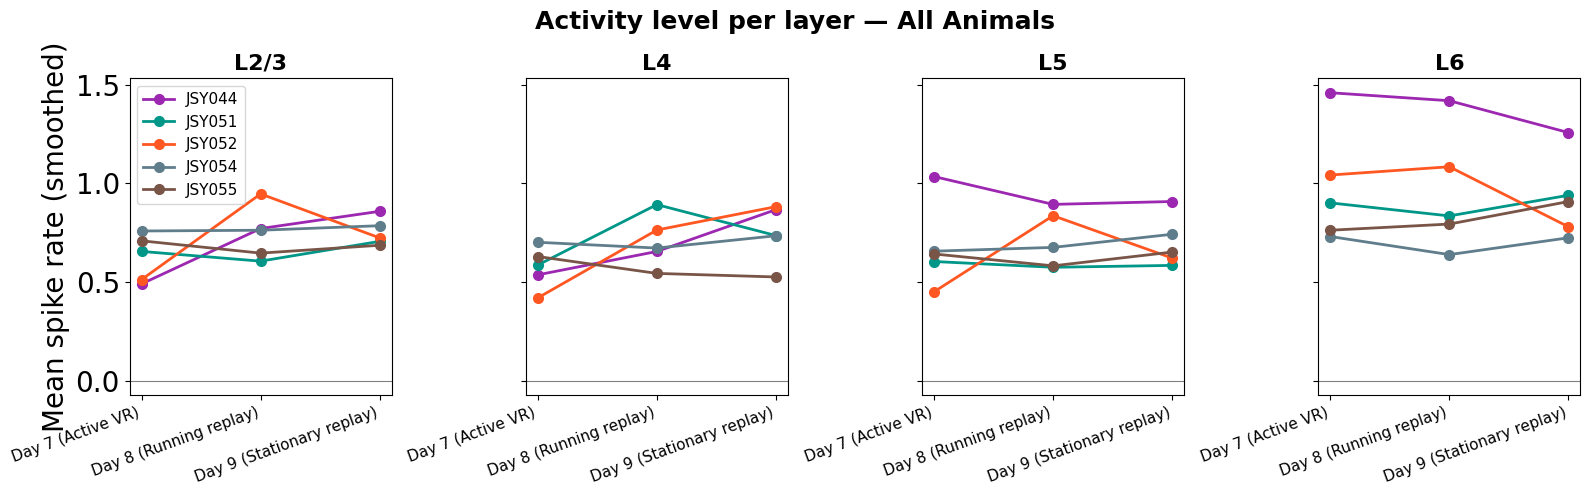

In [53]:
import glob as _glob
import h5py as _h5py

LAYER_KEYS = {'L2_3': 'L2/3', 'L4': 'L4', 'L5': 'L5', 'L6': 'L6'}


def compute_activity_per_layer(preproc_folder, smi_path):
    h5s = _glob.glob(os.path.join(preproc_folder, '*_preproc*.h5'))
    if not h5s or not os.path.isfile(smi_path):
        return None
    result = {}
    with _h5py.File(h5s[0], 'r') as fp, _h5py.File(smi_path, 'r') as fs:
        spks = fp['smoothed_spks_temporal'][:]
        mean_per_cell = spks.mean(axis=1)
        result['ALL'] = {'mean': mean_per_cell.mean(), 'sd': mean_per_cell.std(), 'n': len(mean_per_cell)}
        for hk, lname in LAYER_KEYS.items():
            if 'layer_smi' in fs and hk in fs['layer_smi']:
                idx = fs['layer_smi'][hk]['cell_indices'][:]
                if len(idx):
                    vals = mean_per_cell[idx]
                    result[lname] = {'mean': vals.mean(), 'sd': vals.std(), 'n': len(idx)}
    return result


# Collect activity per session
activity_data = {}
for sess in all_sessions:
    animal = sess['animal_id']
    # find Day7 smi path from SESSIONS config
    day7_smi = next(s['lastday_smi'] for s in SESSIONS if s['animal_id'] == animal)
    paths = {
        'Day7': (sess['lastday_preproc'],                              day7_smi),
        'Day8': (os.path.dirname(sess['openloop_active_smi']),     sess['openloop_active_smi']),
        'Day9': (os.path.dirname(sess['openloop_stationary_smi']), sess['openloop_stationary_smi']),
    }
    activity_data[animal] = {
        cond: compute_activity_per_layer(preproc_dir, smi_path)
        for cond, (preproc_dir, smi_path) in paths.items()
    }


# Per-animal bar plots
for sess in all_sessions:
    animal = sess['animal_id']
    ad = activity_data[animal]

    fig, axes = plt.subplots(1, len(LAYER_NAMES), figsize=(4 * len(LAYER_NAMES), 5), sharey=True)
    for ax, layer in zip(axes, LAYER_NAMES):
        for ci, (cond, color) in enumerate(zip(['Day7', 'Day8', 'Day9'], COND_COLORS)):
            d = ad.get(cond) or {}
            if layer in d:
                ax.bar(ci, d[layer]['mean'], color=color, alpha=0.8, width=0.6,
                       yerr=d[layer]['sd'], capsize=4, error_kw={'lw': 1.5})
                ax.text(ci, d[layer]['mean'] + d[layer]['sd'] + 0.02,
                        f"n={d[layer]['n']}", ha='center', fontsize=9)
        ax.set_title(layer, fontsize=16, fontweight='bold')
        ax.set_xticks(range(3))
        ax.set_xticklabels([l.replace('\n', ' ') for l in COND_LABELS], fontsize=11, rotation=20, ha='right')
        ax.axhline(0, color='gray', lw=0.8)
    axes[0].set_ylabel('Mean spike rate (smoothed)')
    fig.suptitle(f'{animal} — Activity level per layer', fontsize=18, fontweight='bold')
    plt.tight_layout()
    save_path = os.path.join(sess['output_dir'], f'ConfoundCheck1_Activity_{animal}.png')
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved: {save_path}')
    plt.show()


# Cross-animal line plot
fig, axes = plt.subplots(1, len(LAYER_NAMES), figsize=(4 * len(LAYER_NAMES), 5), sharey=True)
for ax, layer in zip(axes, LAYER_NAMES):
    for sess, anim_color in zip(all_sessions, ANIMAL_COLORS):
        animal = sess['animal_id']
        vals = [
            (activity_data[animal].get(cond) or {}).get(layer, {}).get('mean', np.nan)
            for cond in ['Day7', 'Day8', 'Day9']
        ]
        ax.plot(range(3), vals, 'o-', color=anim_color, lw=2, ms=7, label=animal)
    ax.set_title(layer, fontsize=16, fontweight='bold')
    ax.set_xticks(range(3))
    ax.set_xticklabels([l.replace('\n', ' ') for l in COND_LABELS], fontsize=11, rotation=20, ha='right')
    ax.axhline(0, color='gray', lw=0.8)
axes[0].set_ylabel('Mean spike rate (smoothed)')
axes[0].legend(fontsize=11)
fig.suptitle('Activity level per layer — All Animals', fontsize=18, fontweight='bold')
plt.tight_layout()
save_path = os.path.join(ACROSS_ANIMALS_DIR, 'ConfoundCheck1_Activity_AllAnimals.png')
fig.savefig(save_path, dpi=150, bbox_inches='tight')
print(f'Saved: {save_path}')
plt.show()


---
## Confound Check 2 — Lap parsing validation
Confirm that lap starts in Day 8 replay sessions correspond to VR position resets (~0 cm), validating the odd/even cross-validation.

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY044_ChronicImaging\OpenLoopVR_Analysis_day7\ConfoundCheck2_LapParsing_JSY044.png


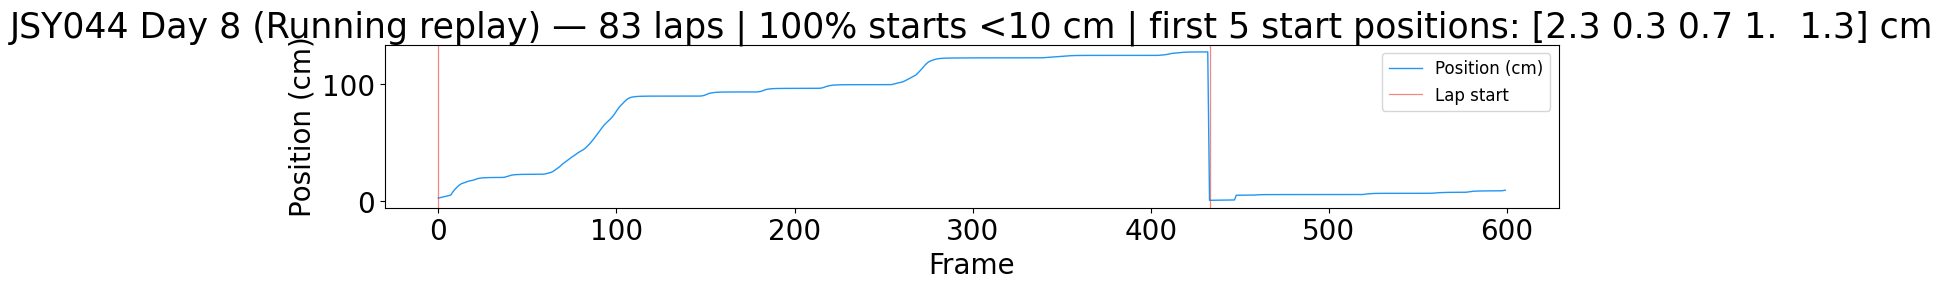

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY051_ChronicImaging\OpenLoopVR_Analysis_day4\ConfoundCheck2_LapParsing_JSY051.png


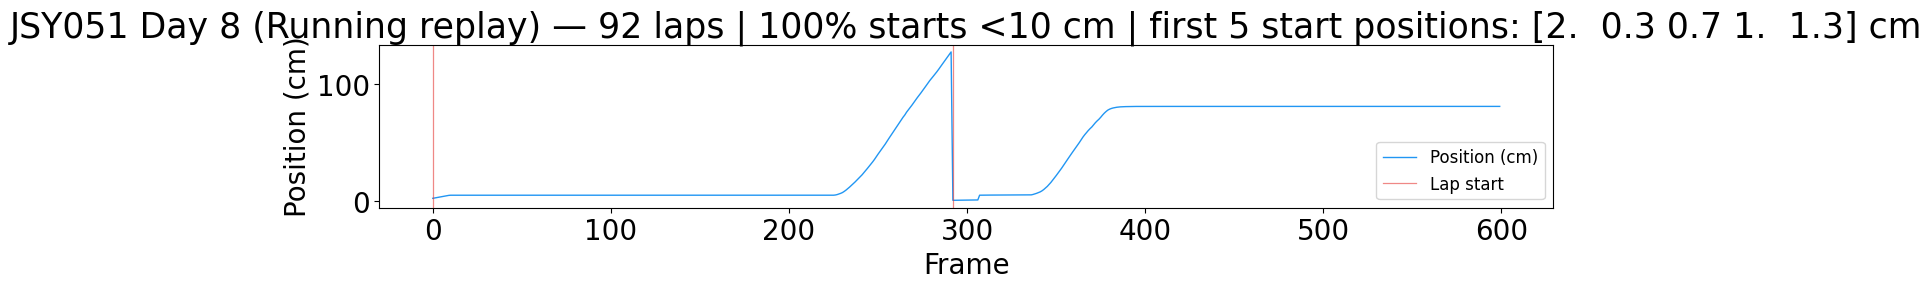

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY052_ChronicImaging\OpenLoopVR_Analysis_day7\ConfoundCheck2_LapParsing_JSY052.png


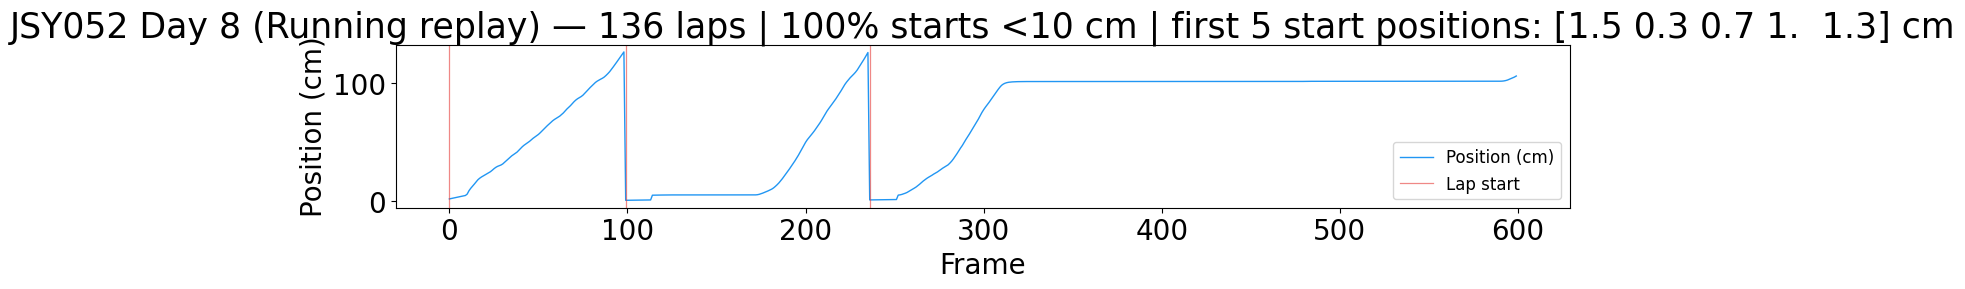

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY054_ChronicImaging\OpenLoopVR_Analysis_day7\ConfoundCheck2_LapParsing_JSY054.png


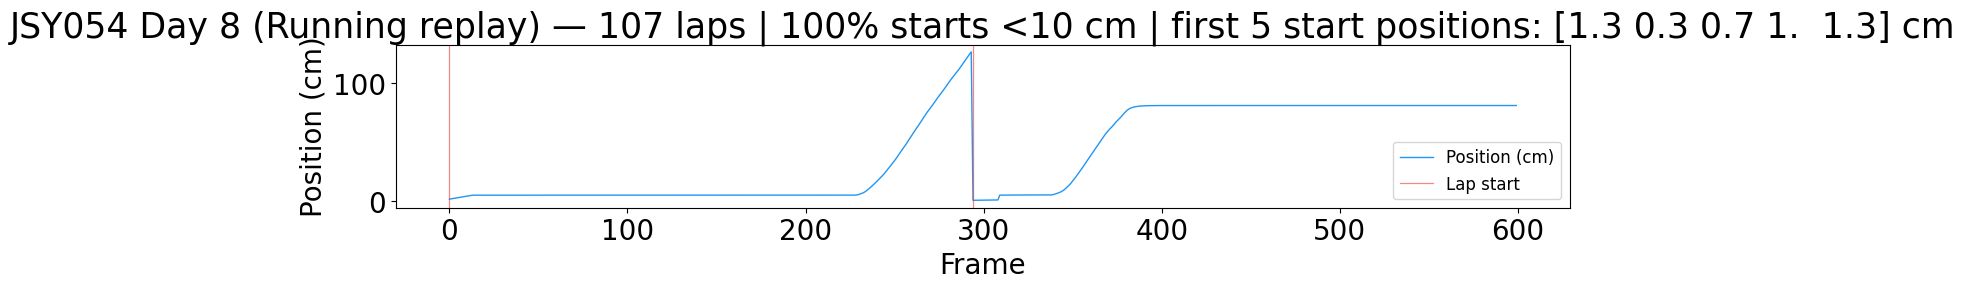

Saved: D:\V1_SpatialModulation\2p\V1_prism\JSY055_ChronicImaging\OpenLoopVR_Analysis_day7\ConfoundCheck2_LapParsing_JSY055.png


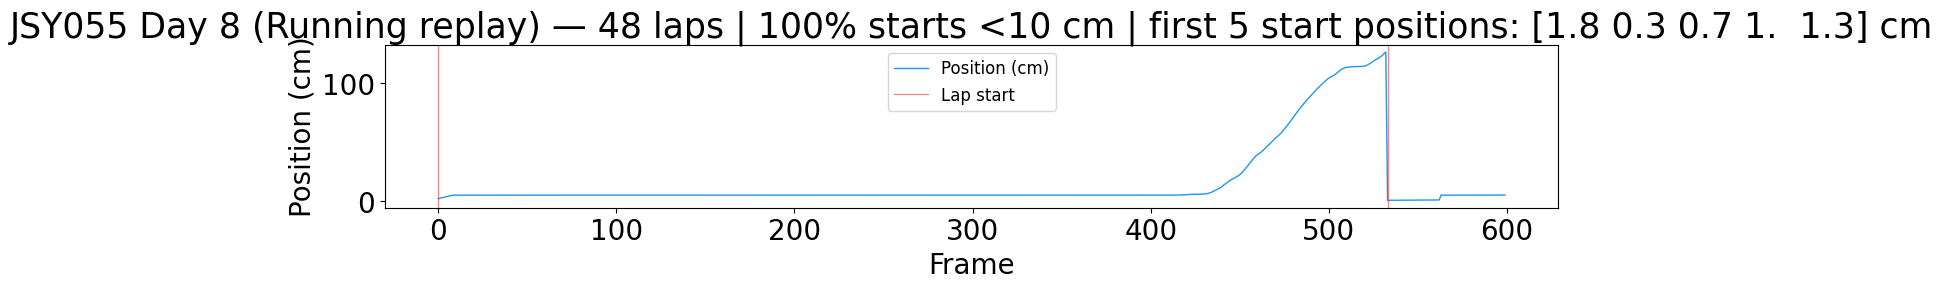

In [54]:
# Per-animal: plot location_cm with lap_start markers for Day 8
for sess in all_sessions:
    animal = sess['animal_id']
    preproc_folder = os.path.dirname(sess['openloop_active_smi'])
    import glob as _glob2
    h5s = _glob2.glob(os.path.join(preproc_folder, '*_preproc*.h5'))
    if not h5s:
        print(f'{animal}: no Day8 preproc')
        continue

    import h5py as _h5py2
    with _h5py2.File(h5s[0], 'r') as f:
        loc        = f['location_cm'][:]
        lap_starts = f['lap_starts'][:]

    loc_at_starts = loc[lap_starts]
    pct_near_zero = np.mean(loc_at_starts < 10) * 100

    n_show = min(600, len(loc))
    fig, ax = plt.subplots(figsize=(13, 3))
    ax.plot(loc[:n_show], color='#2196F3', lw=1, label='Position (cm)')
    first_shown = True
    for ls in lap_starts:
        if ls < n_show:
            ax.axvline(ls, color='#E53935', lw=0.9, alpha=0.6,
                       label='Lap start' if first_shown else '')
            first_shown = False
    ax.set_xlabel('Frame')
    ax.set_ylabel('Position (cm)')
    ax.set_title(
        f'{animal} Day 8 (Running replay) — {len(lap_starts)} laps | '
        f'{pct_near_zero:.0f}% starts <10 cm | '
        f'first 5 start positions: {np.round(loc[lap_starts[:5]], 1)} cm'
    )
    ax.legend(fontsize=12)
    plt.tight_layout()
    save_path = os.path.join(sess['output_dir'], f'ConfoundCheck2_LapParsing_{animal}.png')
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f'Saved: {save_path}')
    plt.show()
